# Pancreas analysis setup

Load packages, cohort/reference metadata, method order, colors, and the shared condition labels used by all pancreas analyses.

In [1]:
import os
import warnings
from collections import OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
import math
from matplotlib.lines import Line2D
import itertools
from scipy.stats import pearsonr

STYLE_HBA1C_BETA = {
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 9,
    "axes.linewidth": 0.6,
    "xtick.labelsize": 5.8,
    "ytick.labelsize": 5.8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "legend.frameon": False,
}
METHODS = [
    {"file_name": "SABER", "display_name": "SABER"},
    {"file_name": "DWLS", "display_name": "DWLS"},
    {"file_name": "BayesPrism", "display_name": "BayesPrism"},
    {"file_name": "Scadenpytorch", "display_name": "Scaden"},
    {"file_name": "TAPE", "display_name": "TAPE"},
    {"file_name": "RNASieve", "display_name": "RNASieve"},
    {"file_name": "SCDC", "display_name": "SCDC"},
    {"file_name": "MuSiC", "display_name": "MuSiC"},
    {"file_name": "BisqueRNA", "display_name": "BisqueRNA"},
    {"file_name": "NNLS", "display_name": "NNLS"},
]
ALL_BULK_DATASETS = OrderedDict(
    [
        (
            "array1",
            {
                "bulk_label": "Array:GSE54279",
                "meta_path": "/Path/to/pancreas/data/array1/metadata.csv",
                "result_dir": "/Path/to/pancreas/results/array1",
            },
        ),
        (
            "array2",
            {
                "bulk_label": "Array:GSE25724",
                "meta_path": "/Path/to/pancreas/data/array2/metadata.csv",
                "result_dir": "/Path/to/pancreas/results/array2",
            },
        ),
        (
            "array3",
            {
                "bulk_label": "Array:GSE76895",
                "meta_path": "/Path/to/pancreas/data/array3/metadata.csv",
                "result_dir": "/Path/to/pancreas/results/array3",
            },
        ),
        (
            "array4",
            {
                "bulk_label": "Array:GSE76894",
                "meta_path": "/Path/to/pancreas/data/array4/metadata.csv",
                "result_dir": "/Path/to/pancreas/results/array4",
            },
        ),
        (
            "hba1c",
            {
                "bulk_label": "RNA-seq:GSE50244",
                "meta_path": "/Path/to/pancreas/data/hba1c/metadata.csv",
                "result_dir": "/Path/to/pancreas/results/hba1c",
            },
        ),
        (
            "t2d",
            {
                "bulk_label": "RNA-seq:GSE159984",
                "meta_path": "/Path/to/pancreas/data/t2d/metadata.csv",
                "result_dir": "/Path/to/pancreas/results/t2d",
            },
        ),
        (
            "t2dprogression",
            {
                "bulk_label": "RNA-seq:GSE164416",
                "meta_path": "/Path/to/pancreas/data/t2dprogression/metadata.csv",
                "result_dir": "/Path/to/pancreas/results/t2dprogression",
            },
        ),
        (
            "humanislet",
            {
                "bulk_label": "RNA-seq:Humanislet",
                "meta_path": "/Path/to/pancreas/data/humanislet/metadata.csv",
                "result_dir": "/Path/to/pancreas/results/humanislet",
            },
        ),
    ]
)
REFERENCE_CONFIGS = OrderedDict(
    [
        ("ref3", "GSE221156"),
        ("ref2", "E-MTAB-5061"),
        ("ref1", "GSE84133"),
        ("ref4", "GSE153855"),
        ("ref5", "GSE183568"),
        ("ref6", "GSE269204"),
        ("combined", "Combined"),
    ]
)
SAVE_DIR = "/Path/to/output/pancreas"
STYLE_IMMUNE_HEATMAP = {
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 10,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "text.color": "black",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "legend.frameon": False,
}
T2D_BOXPLOTS_CELLTYPE = "beta"
STYLE_BENCHMARK = {
    "font.family": "DejaVu Sans",
    "font.size": 6.5,
    "axes.linewidth": 0.55,
    "axes.labelsize": 6.5,
    "axes.titlesize": 7.5,
    "axes.titleweight": "bold",
    "xtick.labelsize": 5.2,
    "ytick.labelsize": 5.8,
    "legend.fontsize": 6,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 2.2,
    "ytick.major.size": 2.2,
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "savefig.bbox": "tight",
}
BENCHMARK_CELLTYPES = [
    "immune",
    "beta",
    "acinar",
    "alpha",
    "delta",
    "gamma",
    "ductal",
    "endothelial",
    "stellate",
]
SCENARIOS = {
    "GSE54279_Ref_ref3": {
        "meta_path": "/Path/to/pancreas/data/array1/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array1",
        "ref_key": "ref3",
    },
    "GSE54279_Ref_ref2": {
        "meta_path": "/Path/to/pancreas/data/array1/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array1",
        "ref_key": "ref2",
    },
    "GSE54279_Ref_ref1": {
        "meta_path": "/Path/to/pancreas/data/array1/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array1",
        "ref_key": "ref1",
    },
    "GSE54279_Ref_ref4": {
        "meta_path": "/Path/to/pancreas/data/array1/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array1",
        "ref_key": "ref4",
    },
    "GSE54279_Ref_ref5": {
        "meta_path": "/Path/to/pancreas/data/array1/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array1",
        "ref_key": "ref5",
    },
    "GSE54279_Ref_ref6": {
        "meta_path": "/Path/to/pancreas/data/array1/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array1",
        "ref_key": "ref6",
    },
    "GSE54279_Ref_combined": {
        "meta_path": "/Path/to/pancreas/data/array1/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array1",
        "ref_key": "combined",
    },
    "GSE25724_Ref_ref3": {
        "meta_path": "/Path/to/pancreas/data/array2/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array2",
        "ref_key": "ref3",
    },
    "GSE25724_Ref_ref2": {
        "meta_path": "/Path/to/pancreas/data/array2/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array2",
        "ref_key": "ref2",
    },
    "GSE25724_Ref_ref1": {
        "meta_path": "/Path/to/pancreas/data/array2/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array2",
        "ref_key": "ref1",
    },
    "GSE25724_Ref_ref4": {
        "meta_path": "/Path/to/pancreas/data/array2/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array2",
        "ref_key": "ref4",
    },
    "GSE25724_Ref_ref5": {
        "meta_path": "/Path/to/pancreas/data/array2/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array2",
        "ref_key": "ref5",
    },
    "GSE25724_Ref_ref6": {
        "meta_path": "/Path/to/pancreas/data/array2/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array2",
        "ref_key": "ref6",
    },
    "GSE25724_Ref_combined": {
        "meta_path": "/Path/to/pancreas/data/array2/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array2",
        "ref_key": "combined",
    },
    "GSE76895_Ref_ref3": {
        "meta_path": "/Path/to/pancreas/data/array3/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array3",
        "ref_key": "ref3",
    },
    "GSE76895_Ref_ref2": {
        "meta_path": "/Path/to/pancreas/data/array3/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array3",
        "ref_key": "ref2",
    },
    "GSE76895_Ref_ref1": {
        "meta_path": "/Path/to/pancreas/data/array3/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array3",
        "ref_key": "ref1",
    },
    "GSE76895_Ref_ref4": {
        "meta_path": "/Path/to/pancreas/data/array3/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array3",
        "ref_key": "ref4",
    },
    "GSE76895_Ref_ref5": {
        "meta_path": "/Path/to/pancreas/data/array3/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array3",
        "ref_key": "ref5",
    },
    "GSE76895_Ref_ref6": {
        "meta_path": "/Path/to/pancreas/data/array3/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array3",
        "ref_key": "ref6",
    },
    "GSE76895_Ref_combined": {
        "meta_path": "/Path/to/pancreas/data/array3/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array3",
        "ref_key": "combined",
    },
    "GSE76894_Ref_ref3": {
        "meta_path": "/Path/to/pancreas/data/array4/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array4",
        "ref_key": "ref3",
    },
    "GSE76894_Ref_ref2": {
        "meta_path": "/Path/to/pancreas/data/array4/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array4",
        "ref_key": "ref2",
    },
    "GSE76894_Ref_ref1": {
        "meta_path": "/Path/to/pancreas/data/array4/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array4",
        "ref_key": "ref1",
    },
    "GSE76894_Ref_ref4": {
        "meta_path": "/Path/to/pancreas/data/array4/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array4",
        "ref_key": "ref4",
    },
    "GSE76894_Ref_ref5": {
        "meta_path": "/Path/to/pancreas/data/array4/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array4",
        "ref_key": "ref5",
    },
    "GSE76894_Ref_ref6": {
        "meta_path": "/Path/to/pancreas/data/array4/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array4",
        "ref_key": "ref6",
    },
    "GSE76894_Ref_combined": {
        "meta_path": "/Path/to/pancreas/data/array4/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/array4",
        "ref_key": "combined",
    },
    "GSE50244_Ref_ref3": {
        "meta_path": "/Path/to/pancreas/data/hba1c/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/hba1c",
        "ref_key": "ref3",
    },
    "GSE50244_Ref_ref2": {
        "meta_path": "/Path/to/pancreas/data/hba1c/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/hba1c",
        "ref_key": "ref2",
    },
    "GSE50244_Ref_ref1": {
        "meta_path": "/Path/to/pancreas/data/hba1c/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/hba1c",
        "ref_key": "ref1",
    },
    "GSE50244_Ref_ref4": {
        "meta_path": "/Path/to/pancreas/data/hba1c/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/hba1c",
        "ref_key": "ref4",
    },
    "GSE50244_Ref_ref5": {
        "meta_path": "/Path/to/pancreas/data/hba1c/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/hba1c",
        "ref_key": "ref5",
    },
    "GSE50244_Ref_ref6": {
        "meta_path": "/Path/to/pancreas/data/hba1c/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/hba1c",
        "ref_key": "ref6",
    },
    "GSE50244_Ref_combined": {
        "meta_path": "/Path/to/pancreas/data/hba1c/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/hba1c",
        "ref_key": "combined",
    },
    "GSE159984_Ref_ref3": {
        "meta_path": "/Path/to/pancreas/data/t2d/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2d",
        "ref_key": "ref3",
    },
    "GSE159984_Ref_ref2": {
        "meta_path": "/Path/to/pancreas/data/t2d/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2d",
        "ref_key": "ref2",
    },
    "GSE159984_Ref_ref1": {
        "meta_path": "/Path/to/pancreas/data/t2d/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2d",
        "ref_key": "ref1",
    },
    "GSE159984_Ref_ref4": {
        "meta_path": "/Path/to/pancreas/data/t2d/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2d",
        "ref_key": "ref4",
    },
    "GSE159984_Ref_ref5": {
        "meta_path": "/Path/to/pancreas/data/t2d/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2d",
        "ref_key": "ref5",
    },
    "GSE159984_Ref_ref6": {
        "meta_path": "/Path/to/pancreas/data/t2d/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2d",
        "ref_key": "ref6",
    },
    "GSE159984_Ref_combined": {
        "meta_path": "/Path/to/pancreas/data/t2d/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2d",
        "ref_key": "combined",
    },
    "GSE164416_Ref_ref3": {
        "meta_path": "/Path/to/pancreas/data/t2dprogression/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2dprogression",
        "ref_key": "ref3",
    },
    "GSE164416_Ref_ref2": {
        "meta_path": "/Path/to/pancreas/data/t2dprogression/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2dprogression",
        "ref_key": "ref2",
    },
    "GSE164416_Ref_ref1": {
        "meta_path": "/Path/to/pancreas/data/t2dprogression/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2dprogression",
        "ref_key": "ref1",
    },
    "GSE164416_Ref_ref4": {
        "meta_path": "/Path/to/pancreas/data/t2dprogression/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2dprogression",
        "ref_key": "ref4",
    },
    "GSE164416_Ref_ref5": {
        "meta_path": "/Path/to/pancreas/data/t2dprogression/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2dprogression",
        "ref_key": "ref5",
    },
    "GSE164416_Ref_ref6": {
        "meta_path": "/Path/to/pancreas/data/t2dprogression/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2dprogression",
        "ref_key": "ref6",
    },
    "GSE164416_Ref_combined": {
        "meta_path": "/Path/to/pancreas/data/t2dprogression/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/t2dprogression",
        "ref_key": "combined",
    },
    "Humanislet_Ref_ref3": {
        "meta_path": "/Path/to/pancreas/data/humanislet/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/humanislet",
        "ref_key": "ref3",
    },
    "Humanislet_Ref_ref2": {
        "meta_path": "/Path/to/pancreas/data/humanislet/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/humanislet",
        "ref_key": "ref2",
    },
    "Humanislet_Ref_ref1": {
        "meta_path": "/Path/to/pancreas/data/humanislet/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/humanislet",
        "ref_key": "ref1",
    },
    "Humanislet_Ref_ref4": {
        "meta_path": "/Path/to/pancreas/data/humanislet/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/humanislet",
        "ref_key": "ref4",
    },
    "Humanislet_Ref_ref5": {
        "meta_path": "/Path/to/pancreas/data/humanislet/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/humanislet",
        "ref_key": "ref5",
    },
    "Humanislet_Ref_ref6": {
        "meta_path": "/Path/to/pancreas/data/humanislet/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/humanislet",
        "ref_key": "ref6",
    },
    "Humanislet_Ref_combined": {
        "meta_path": "/Path/to/pancreas/data/humanislet/metadata.csv",
        "result_dir": "/Path/to/pancreas/results/humanislet",
        "ref_key": "combined",
    },
}

def p_to_star(p, include_near=False, nan_label="n.s."):
    if pd.isna(p):
        return nan_label
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if include_near and p < 0.1:
        return "near"
    return "n.s."

def normalize_condition(value):
    if pd.isna(value):
        return value
    label = " ".join(str(value).strip().lower().replace("_", " ").replace("-", " ").split())
    if label in {"normal", "control", "ctrl", "healthy", "health", "nd", "non diabetic", "nondiabetic", "non diabetes", "non diabetes mellitus", "without diabetes", "no diabetes", "non t2d", "nt2d"}:
        return "ND"
    if label in {"t2d", "type2diabetes", "type 2 diabetes", "type 2 diabetic", "type ii diabetes", "type ii diabetic", "diabetic", "diabetes", "dm", "t2dm"}:
        return "T2D"
    if label in {"t3cd", "t3cdm", "type 3c diabetes", "type3cdiabetes", "type 3c diabetic"}:
        return "T3cD"
    return str(value).strip()

def count_analysis_samples(meta_path, pred_path, celltype="beta"):
    metadata = pd.read_csv(meta_path, index_col=0)[["condition"]]
    prediction = pd.read_csv(pred_path, index_col=0)[[celltype]]
    metadata.index = metadata.index.astype(str)
    prediction.index = prediction.index.astype(str)
    metadata["condition"] = metadata["condition"].map(normalize_condition)
    prediction[celltype] = pd.to_numeric(prediction[celltype], errors="coerce")
    common = metadata.index.intersection(prediction.index)
    analysis_data = pd.concat([metadata.loc[common], prediction.loc[common]], axis=1)
    return (
        int(analysis_data.loc[analysis_data["condition"] == "ND", celltype].dropna().shape[0]),
        int(analysis_data.loc[analysis_data["condition"] == "T2D", celltype].dropna().shape[0]),
    )

SIGNIFICANCE_COLORS = ["#3498DB", "#E0E0E0", "#F4A6A6", "#E74C3C", "#FFFFFF"]
SIGNIFICANCE_BOUNDS = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]

def consistency_legend_handles():
    return [
        Patch(facecolor="#E74C3C", edgecolor="white", label="Significant & correct direction"),
        Patch(facecolor="#F4A6A6", edgecolor="white", label="0.05 ≤ p < 0.1 & correct direction"),
        Patch(facecolor="#3498DB", edgecolor="white", label="Significant but opposite direction"),
        Patch(facecolor="#E0E0E0", edgecolor="white", label="Not significant"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="Data missing"),
    ]

def condition_scenario(bulk_label, ref_label, dataset_cfg, ref_key):
    return {
        "bulk_label": bulk_label,
        "ref_label": ref_label,
        "meta_path": dataset_cfg["meta_path"],
        "result_dir": dataset_cfg["result_dir"],
        "ref_key": ref_key,
        "g1": "ND",
        "g2": "T2D",
    }

warnings.filterwarnings("ignore")


## Relate beta-cell proportion to HbA1c

Fit sample-level OLS models for matched HbA1c and beta-cell predictions across references and save the regression panel.

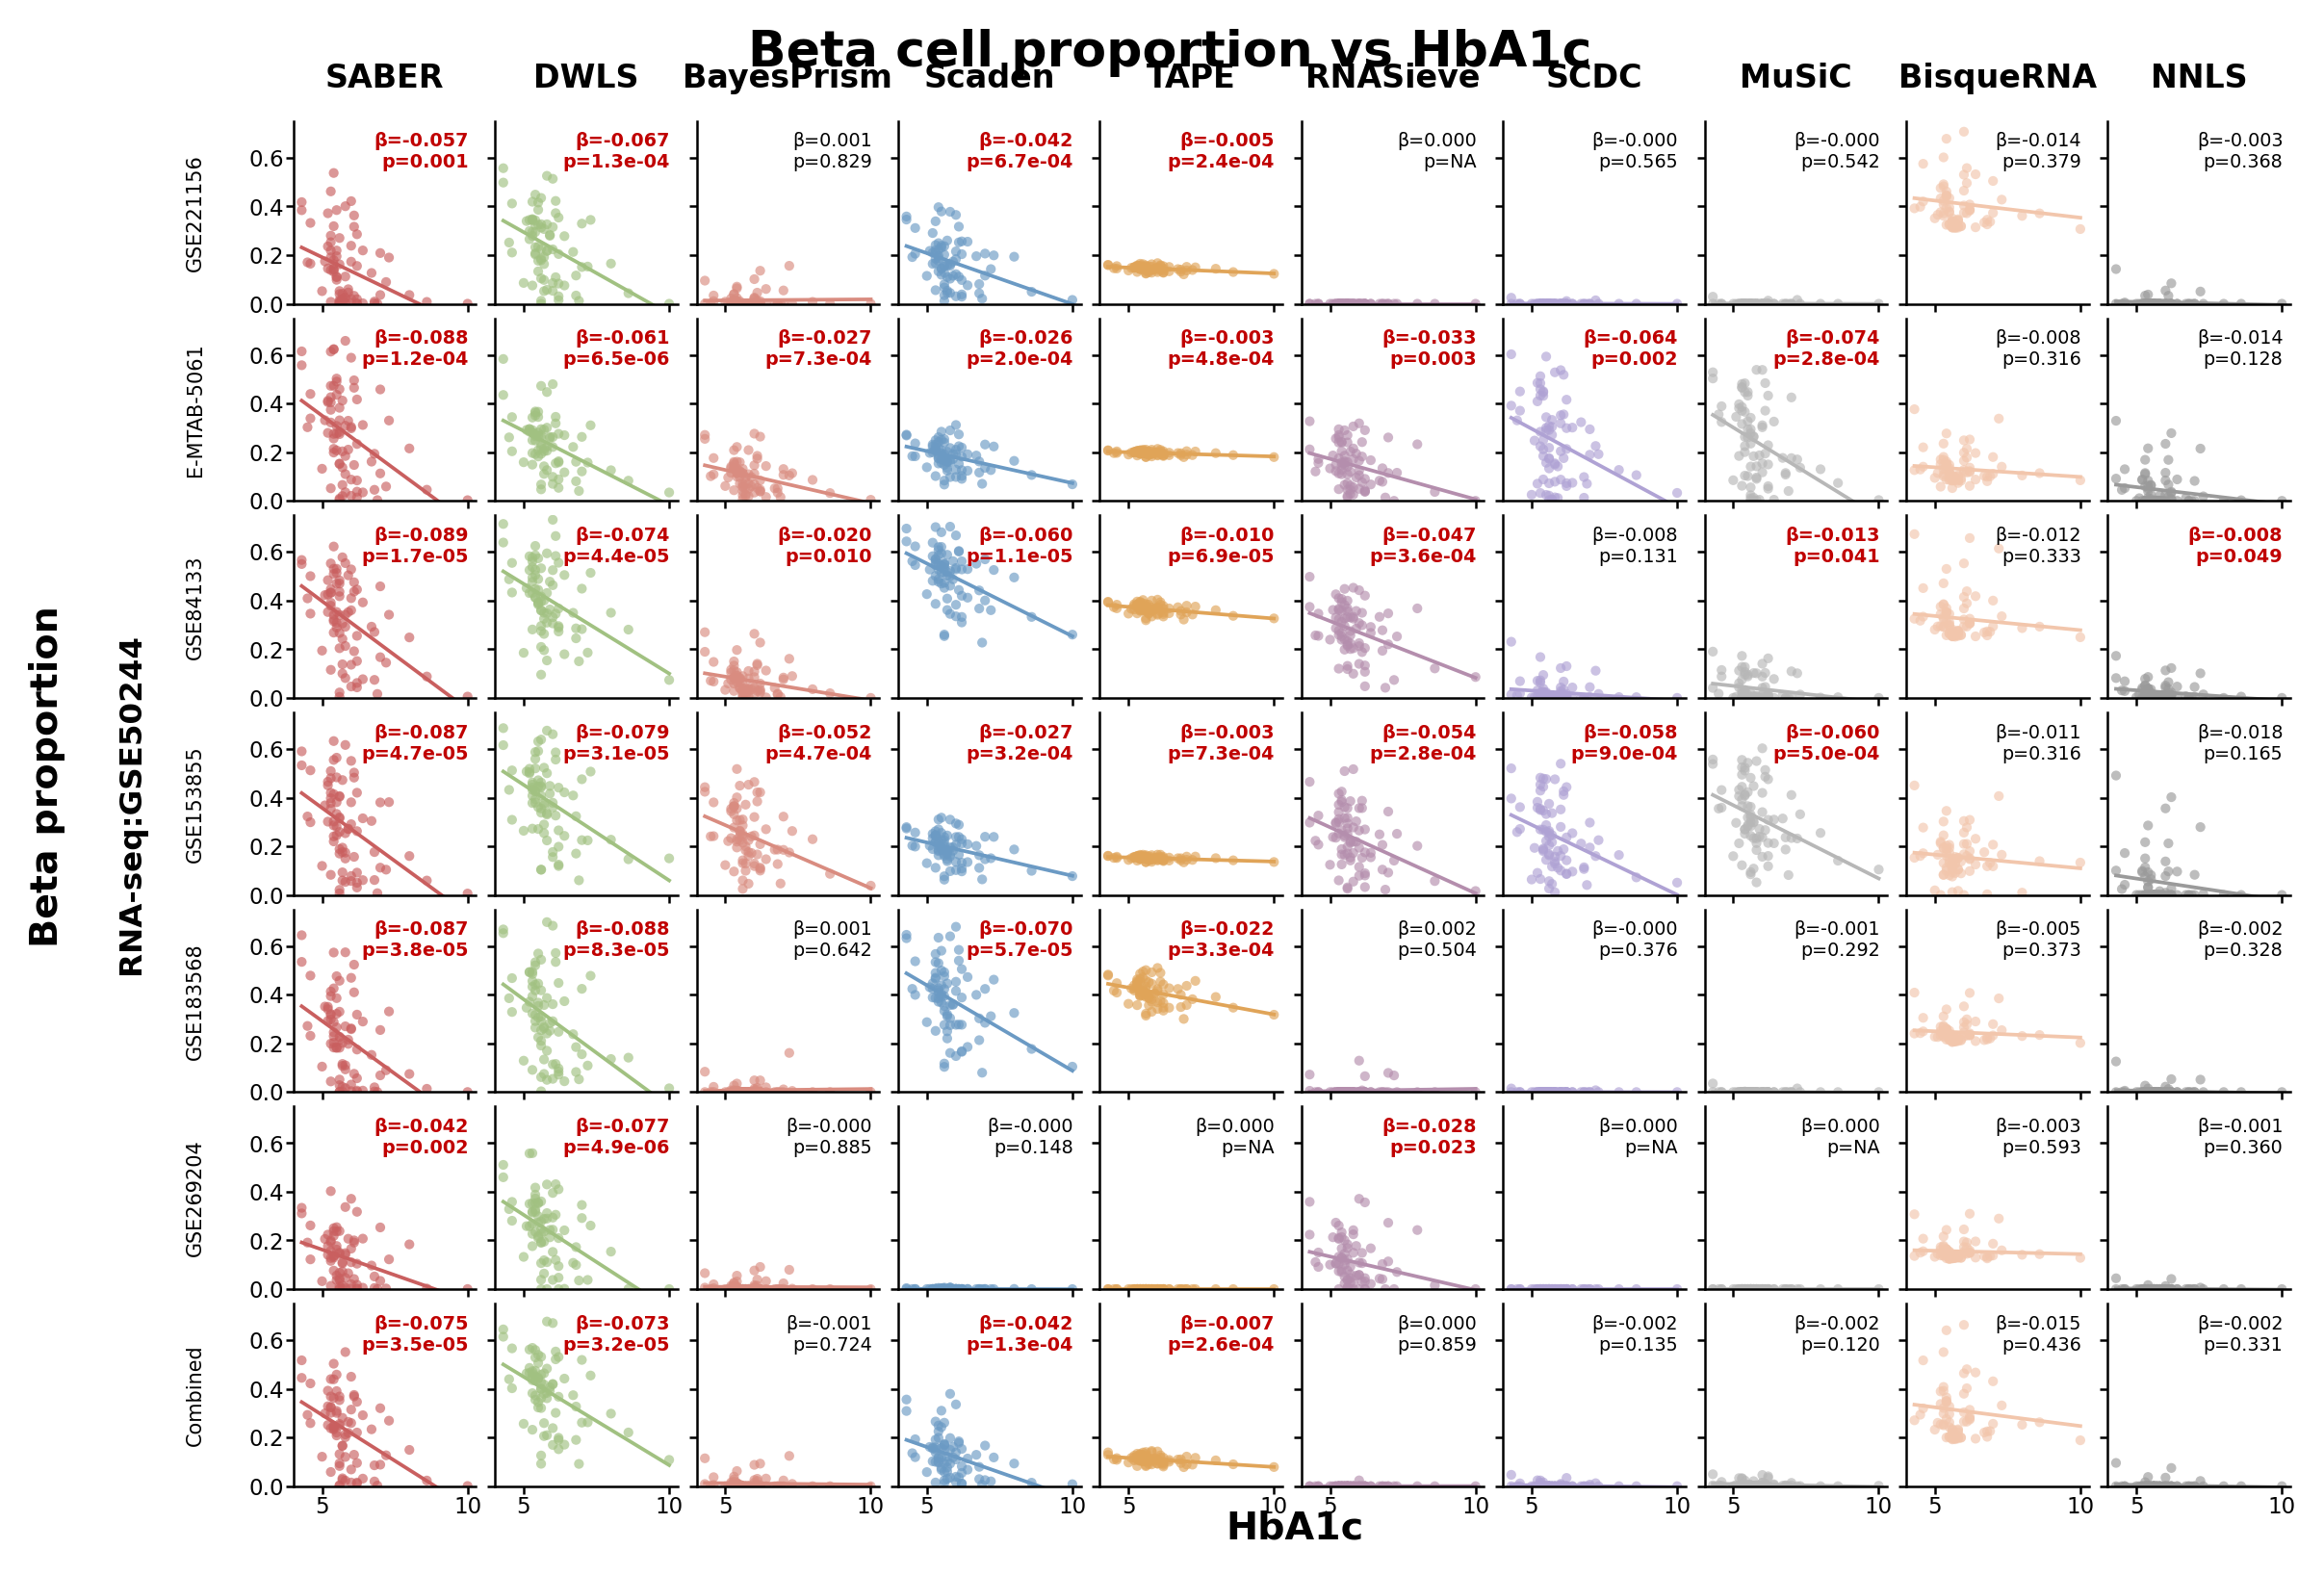

In [2]:
plt.rcParams.update(STYLE_HBA1C_BETA)
method_file_list = [m["file_name"] for m in METHODS]
method_display_list = [m["display_name"] for m in METHODS]
scenarios = []
for dataset_key, dataset_cfg in ALL_BULK_DATASETS.items():
    if dataset_key != "hba1c":
        continue
    if not "hba1c" in pd.read_csv(dataset_cfg["meta_path"], nrows=0).columns:
        continue
    for ref_key, ref_label in REFERENCE_CONFIGS.items():
        scenarios.append(
            {
                "bulk_label": dataset_cfg["bulk_label"],
                "ref": ref_label,
                "ref_key": ref_key,
                "meta_path": dataset_cfg["meta_path"],
                "result_dir": dataset_cfg["result_dir"],
            }
        )
bulk_to_rows = OrderedDict()
for i, cfg in enumerate(scenarios):
    bulk_to_rows.setdefault(cfg["bulk_label"], []).append(i)
method_colors = {
    "SABER": "#C95F5F",
    "DWLS": "#A1C181",
    "BayesPrism": "#D98C80",
    "Scadenpytorch": "#6B9AC4",
    "TAPE": "#E0A458",
    "RNASieve": "#B48EAD",
    "SCDC": "#AFA2D4",
    "MuSiC": "#B7B7B7",
    "BisqueRNA": "#F2C6AC",
    "NNLS": "#9A9A9A",
}
n_rows = len(scenarios)
n_cols = len(method_file_list)
panel_size = 0.62
fig_width = 1.7 + panel_size * n_cols
fig_height = 1.0 + panel_size * n_rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), squeeze=False)
axes = np.asarray(axes)
fig.suptitle("Beta cell proportion vs HbA1c", fontsize=12.5, fontweight="bold", y=0.985)
for row, cfg in enumerate(scenarios):
    metadata_orig = pd.read_csv(cfg["meta_path"], index_col=0)
    required_cols = ["hba1c"]
    metadata_orig = metadata_orig[required_cols].copy()
    metadata_orig.index = metadata_orig.index.astype(str)
    metadata_orig["hba1c"] = pd.to_numeric(metadata_orig["hba1c"], errors="coerce")
    for col, method_info in enumerate(METHODS):
        method = method_info["file_name"]
        ax = axes[row, col]
        ax.set_box_aspect(1)
        metadata = metadata_orig.copy()
        result_path = os.path.join(cfg["result_dir"], f"{method}_{cfg['ref_key']}.csv")
        prop = pd.read_csv(result_path, index_col=0)
        prop.index = prop.index.astype(str)
        prop["beta"] = pd.to_numeric(prop["beta"], errors="coerce")
        common_idx = metadata.index.intersection(prop.index)
        metadata = metadata.loc[common_idx].copy()
        prop = prop.loc[common_idx].copy()
        metadata[method] = prop["beta"]
        model_df = metadata[["hba1c", method]].dropna().copy()
        if model_df.shape[0] < 5:
            ax.axis("off")
            continue
        X = model_df[["hba1c"]]
        X = sm.add_constant(X)
        y = model_df[method]
        model = sm.OLS(y, X, missing="drop").fit()
        coef = model.params["hba1c"]
        pval = model.pvalues["hba1c"]
        sns.regplot(
            x="hba1c",
            y=method,
            data=model_df,
            ax=ax,
            ci=None,
            scatter_kws={
                "s": 6,
                "color": method_colors[method],
                "alpha": 0.65,
                "edgecolor": "none",
            },
            line_kws={"color": method_colors[method], "linewidth": 0.9},
        )
        ax.set_ylim(0.0, 0.75)
        sig = pval < 0.05
        text_color = "#C00000" if sig else "black"
        text_weight = "bold" if sig else "normal"
        ax.text(
            0.96,
            0.94,
            f"β={coef:.3f}\np={('NA' if pd.isna(pval) else format(pval, '.1e') if pval < 0.001 else format(pval, '.3f'))}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=4.6,
            color=text_color,
            fontweight=text_weight,
        )
        ax.set_title("")
        ax.set_xlabel("")
        ax.set_ylabel("")
        if col != 0:
            ax.set_yticklabels([])
            ax.tick_params(axis="y", length=0)
        if row != n_rows - 1:
            ax.set_xticklabels([])
            ax.tick_params(axis="x", length=0)
        ax.tick_params(axis="both", labelsize=5.5, pad=0.4, length=1.8)
        sns.despine(ax=ax)
fig.subplots_adjust(left=0.115, right=0.992, bottom=0.04, top=0.925, wspace=0.08, hspace=0.08)
fig.canvas.draw()
for col, display_name in enumerate(method_display_list):
    ax = axes[0, col]
    ax.text(
        0.5,
        1.15,
        display_name,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        clip_on=False,
    )
fig.text(0.555, 0.013, "HbA1c", ha="center", va="center", fontsize=9.5, fontweight="bold")
fig.text(
    0.008,
    0.5,
    "Beta proportion",
    ha="center",
    va="center",
    rotation=90,
    fontsize=9.5,
    fontweight="bold",
)
for bulk_name, row_indices in bulk_to_rows.items():
    row_start = row_indices[0]
    row_end = row_indices[-1]
    top_ax = axes[row_start, 0]
    bottom_ax = axes[row_end, 0]
    top_pos = top_ax.get_position()
    bottom_pos = bottom_ax.get_position()
    y_center_group = (top_pos.y1 + bottom_pos.y0) / 2
    fig.text(
        0.045,
        y_center_group,
        bulk_name,
        rotation=90,
        va="center",
        ha="center",
        fontsize=7.8,
        fontweight="bold",
    )
    for row_idx in row_indices:
        ax = axes[row_idx, 0]
        pos = ax.get_position()
        y_center_row = (pos.y0 + pos.y1) / 2
        ref_name = scenarios[row_idx]["ref"]
        ref_label = ref_name
        fig.text(
            0.073,
            y_center_row,
            ref_label,
            rotation=90,
            va="center",
            ha="center",
            fontsize=5.0,
            fontweight="normal",
        )
bulk_items = list(bulk_to_rows.items())
for i in range(len(bulk_items) - 1):
    _, row_indices = bulk_items[i]
    sep_row = row_indices[-1]
    left_pos = axes[sep_row, 0].get_position()
    right_pos = axes[sep_row, -1].get_position()
    y = left_pos.y0 - 0.004
    line = plt.Line2D(
        [left_pos.x0, right_pos.x1],
        [y, y],
        transform=fig.transFigure,
        color="lightgray",
        linewidth=0.6,
        linestyle="--",
    )
    fig.add_artist(line)
for axis in fig.axes:
    axis.tick_params(axis="both", length=2, width=0.6)
    for spine in axis.spines.values():
        spine.set_linewidth(0.6)
save_path = "/Path/to/output/pancreas/hba1c_beta.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches=None)
plt.show()


## Summarize HbA1c association consistency

Classify beta-cell association direction and significance across cohorts, methods, and references, then save the heatmap and its long-form statistics table.

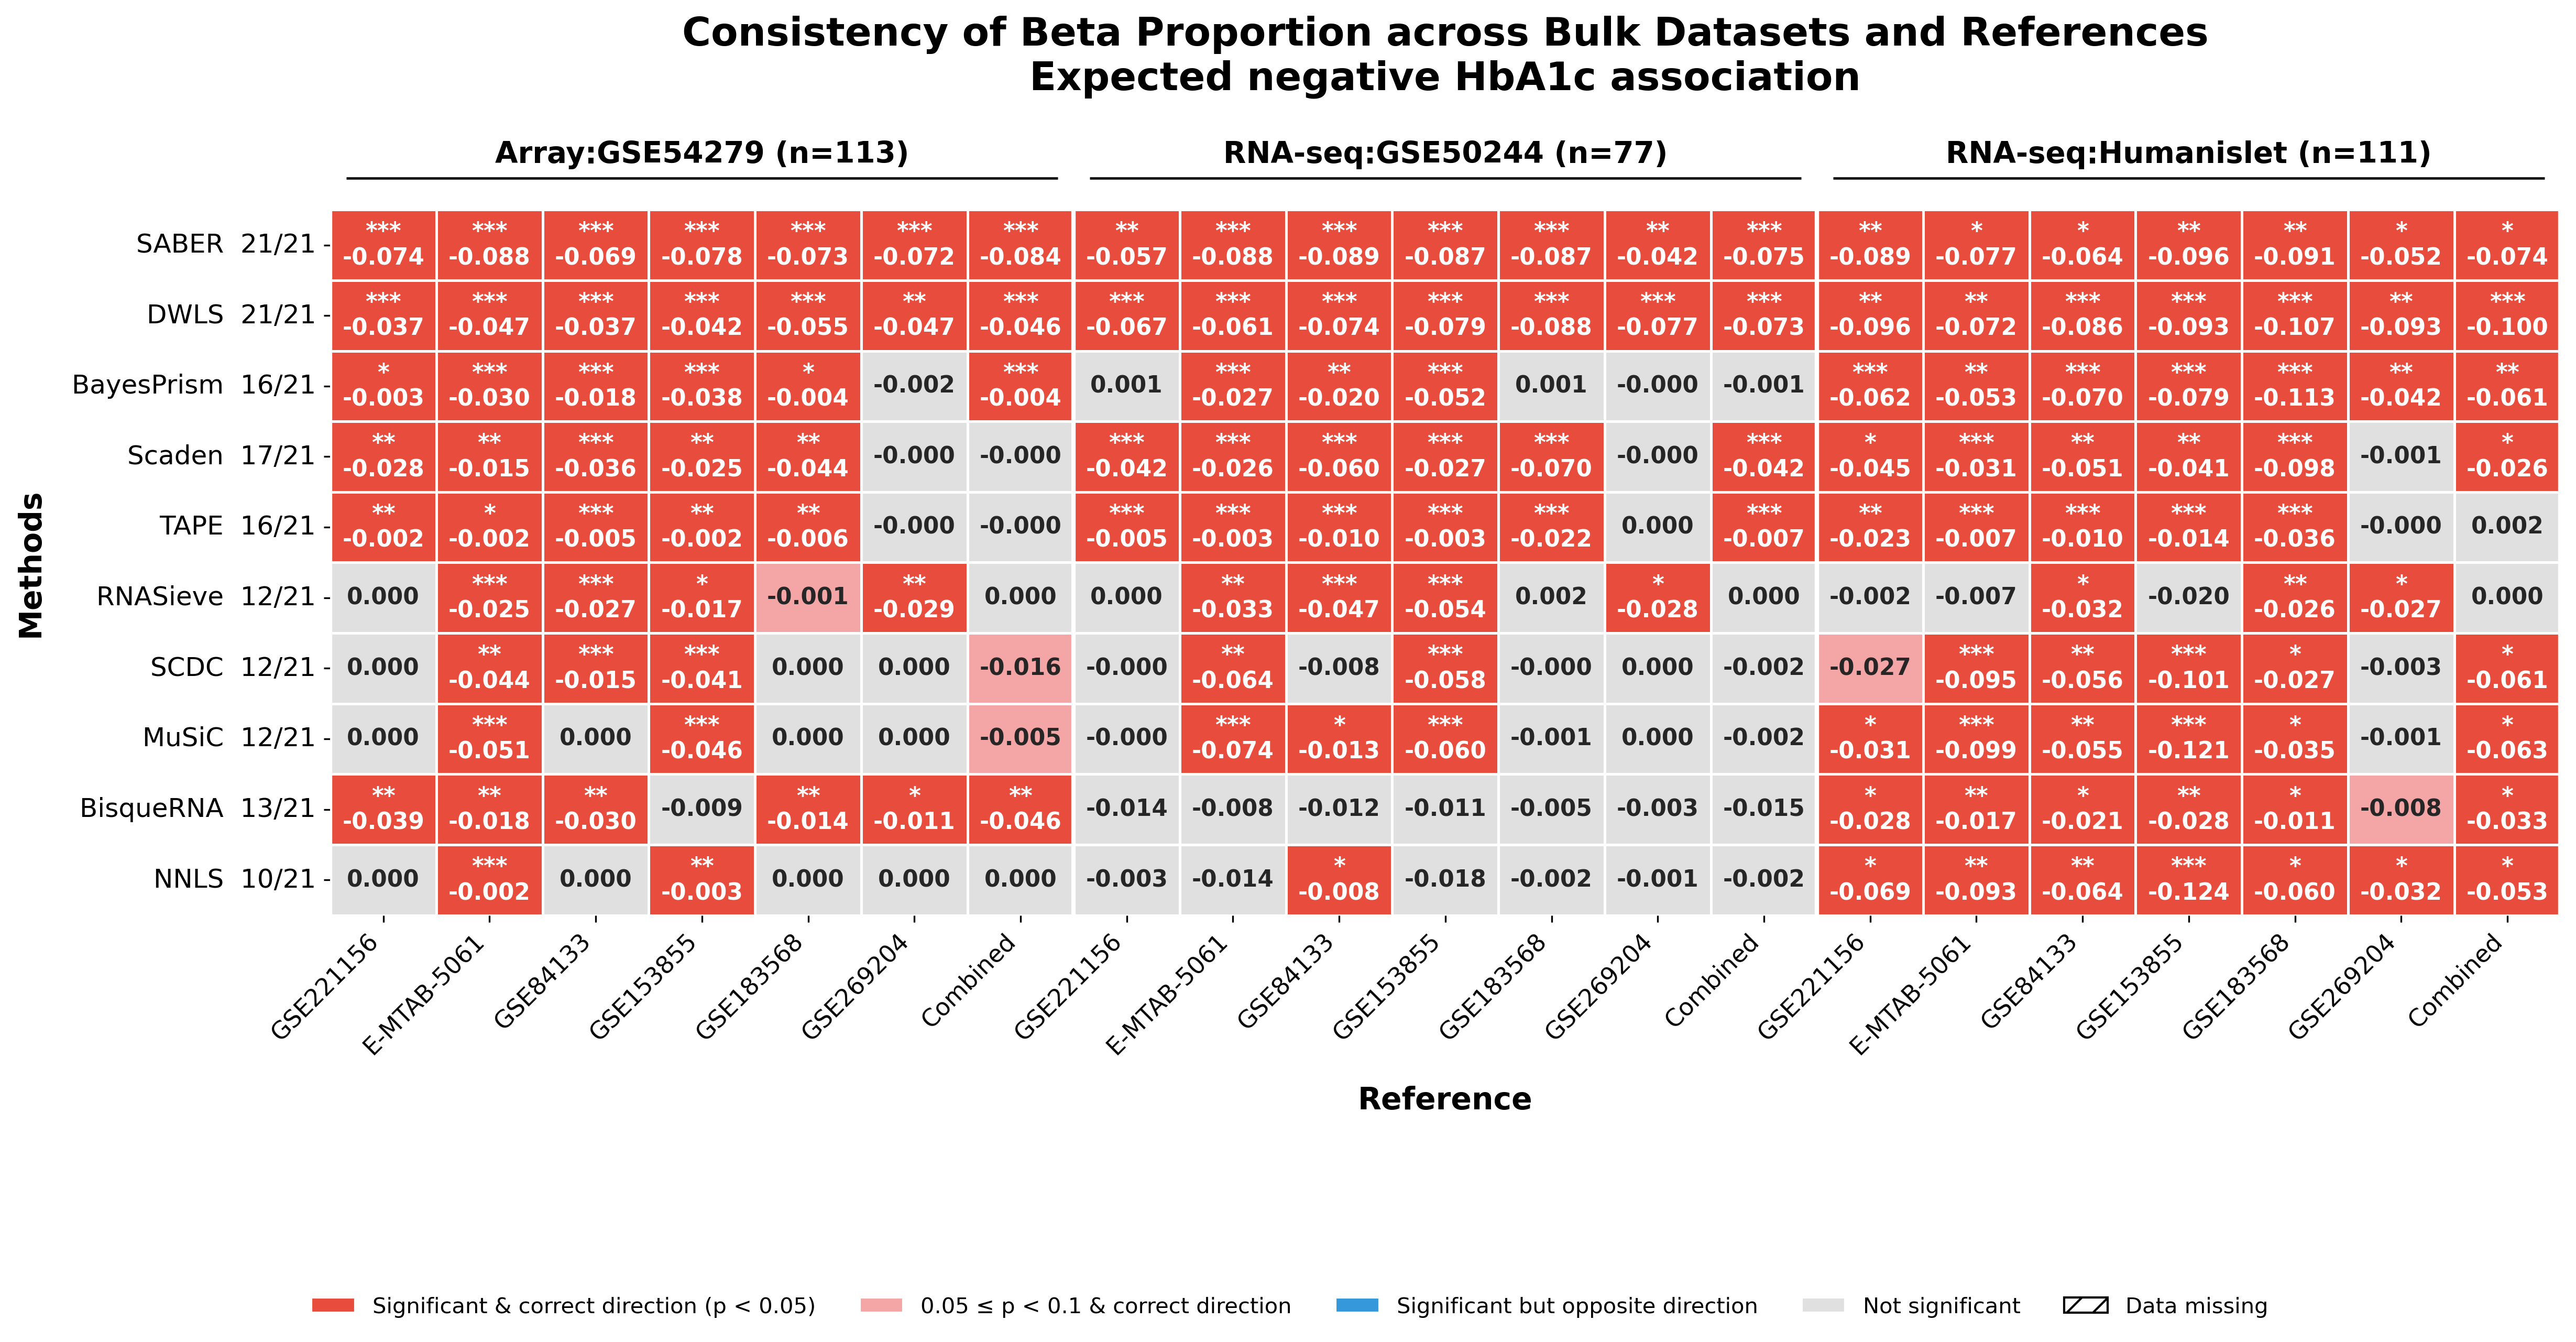

In [3]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "axes.linewidth": 1.0,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "legend.frameon": False,
    }
)
method_file_list = [m["file_name"] for m in METHODS]
method_display_list = [m["display_name"] for m in METHODS]
celltypes = ["beta"]
scenarios = OrderedDict()
for dataset_key, dataset_cfg in ALL_BULK_DATASETS.items():
    if not "hba1c" in pd.read_csv(dataset_cfg["meta_path"], nrows=0).columns:
        continue
    count_metadata = pd.read_csv(dataset_cfg["meta_path"], index_col=0)
    count_prediction = pd.read_csv(
        os.path.join(
            dataset_cfg["result_dir"], f"{method_file_list[0]}_{next(iter(REFERENCE_CONFIGS))}.csv"
        ),
        index_col=0,
    )
    count_metadata.index = count_metadata.index.astype(str)
    count_prediction.index = count_prediction.index.astype(str)
    count_metadata = count_metadata[["hba1c"]].copy()
    count_metadata["hba1c"] = pd.to_numeric(count_metadata["hba1c"], errors="coerce")
    count_prediction = count_prediction[["beta"]].copy()
    count_prediction["beta"] = pd.to_numeric(count_prediction["beta"], errors="coerce")
    count_samples = count_metadata.index.intersection(count_prediction.index)
    n_samples = int(
        pd.concat([count_metadata.loc[count_samples], count_prediction.loc[count_samples]], axis=1)
        .dropna()
        .shape[0]
    )
    bulk_label_with_n = f"{dataset_cfg['bulk_label']} (n={n_samples})"
    for ref_key, ref_label in REFERENCE_CONFIGS.items():
        scenarios[f"{dataset_key}_{ref_key}"] = {
            "meta_path": dataset_cfg["meta_path"],
            "result_dir": dataset_cfg["result_dir"],
            "ref_key": ref_key,
            "bulk_label": bulk_label_with_n,
            "ref_label": ref_label,
        }
scenario_names = list(scenarios.keys())
ref_labels = [scenarios[s]["ref_label"] for s in scenario_names]
bulk_to_cols = OrderedDict()
for i, s in enumerate(scenario_names):
    bulk = scenarios[s]["bulk_label"]
    bulk_to_cols.setdefault(bulk, []).append(i)
p_values_dict = {
    ct: {m: {s: np.nan for s in scenario_names} for m in method_file_list} for ct in celltypes
}
coef_dict = {
    ct: {m: {s: np.nan for s in scenario_names} for m in method_file_list} for ct in celltypes
}
n_dict = {
    ct: {m: {s: np.nan for s in scenario_names} for m in method_file_list} for ct in celltypes
}
for s_name, cfg in scenarios.items():
    metadata = pd.read_csv(cfg["meta_path"], index_col=0)
    metadata = metadata[["hba1c"]].copy()
    metadata.index = metadata.index.astype(str)
    metadata["hba1c"] = pd.to_numeric(metadata["hba1c"], errors="coerce")
    for method in method_file_list:
        pred_path = os.path.join(cfg["result_dir"], f"{method}_{cfg['ref_key']}.csv")
        pred = pd.read_csv(pred_path, index_col=0)
        pred.index = pred.index.astype(str)
        common = metadata.index.intersection(pred.index)
        df = pd.concat([metadata.loc[common], pred.loc[common]], axis=1)
        for celltype in celltypes:
            df[celltype] = pd.to_numeric(df[celltype], errors="coerce")
            model_df = df[["hba1c", celltype]].dropna().copy()
            n_dict[celltype][method][s_name] = model_df.shape[0]
            if model_df.shape[0] < 5:
                continue
            X = model_df[["hba1c"]]
            X = sm.add_constant(X)
            y = model_df[celltype]
            if y.nunique(dropna=True) <= 1:
                coef_dict[celltype][method][s_name] = 0.0
                p_values_dict[celltype][method][s_name] = 1.0
                continue
            model = sm.OLS(y, X, missing="drop").fit()
            coef = model.params.get("hba1c", np.nan)
            p = model.pvalues.get("hba1c", np.nan)
            coef_dict[celltype][method][s_name] = coef
            p_values_dict[celltype][method][s_name] = p
            assert pd.notna(coef) and pd.notna(p)
fig, ax = plt.subplots(figsize=(16.5, 8.8))
cmap = ListedColormap(SIGNIFICANCE_COLORS)
norm = BoundaryNorm(SIGNIFICANCE_BOUNDS, cmap.N)
for celltype in celltypes:
    sig_matrix = pd.DataFrame(index=method_file_list, columns=scenario_names, dtype=float)
    annot_matrix = pd.DataFrame(index=method_file_list, columns=scenario_names, dtype=object)
    for method in method_file_list:
        for s in scenario_names:
            p = p_values_dict[celltype][method][s]
            coef = coef_dict[celltype][method][s]
            assert not (pd.isna(p) or pd.isna(coef))
            is_correct_dir = coef < 0
            if p < 0.05 and is_correct_dir:
                sig_matrix.loc[method, s] = 3.0
                annot_matrix.loc[method, s] = f"{p_to_star(p, include_near=True)}\n{coef:.3f}"
            elif 0.05 <= p < 0.1 and is_correct_dir:
                sig_matrix.loc[method, s] = 2.0
                annot_matrix.loc[method, s] = f"{coef:.3f}"
            elif p < 0.05 and (not is_correct_dir):
                sig_matrix.loc[method, s] = 0.0
                annot_matrix.loc[method, s] = f"{p_to_star(p, include_near=True)}\n{coef:.3f}"
            else:
                sig_matrix.loc[method, s] = 1.0
                annot_matrix.loc[method, s] = f"{coef:.3f}"
    consistency_scores = ((sig_matrix == 3.0) | (sig_matrix == 2.0)).sum(axis=1).astype(int)
    row_labels = [
        f"{display}  {score}/{len(scenario_names)}"
        for display, score in zip(method_display_list, consistency_scores)
    ]
    sig_matrix.index = row_labels
    annot_matrix.index = row_labels
    sig_matrix.columns = ref_labels
    annot_matrix.columns = ref_labels
    sns.heatmap(
        sig_matrix,
        cmap=cmap,
        norm=norm,
        annot=annot_matrix,
        fmt="",
        cbar=False,
        linewidths=1.1,
        linecolor="white",
        annot_kws={"size": 10.5, "weight": "bold"},
        ax=ax,
    )
    ax.set_title(
        f"Consistency of {celltype.capitalize()} Proportion across Bulk Datasets and References\n"
        + "Expected negative HbA1c association",
        fontsize=18,
        fontweight="bold",
        pad=55,
    )
ax.set_xlabel("Reference", fontsize=14, fontweight="bold", labelpad=12)
ax.set_ylabel("Methods", fontsize=14, fontweight="bold", labelpad=12)
ax.tick_params(axis="x", rotation=45, labelsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=12)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
n_methods = len(method_file_list)
for bulk_label, col_indices in bulk_to_cols.items():
    start_col = col_indices[0]
    end_col = col_indices[-1]
    x_center = (start_col + end_col + 1) / 2
    ax.text(
        x_center,
        -0.78,
        bulk_label,
        ha="center",
        va="center",
        fontsize=13.5,
        fontweight="bold",
        clip_on=False,
    )
    ax.hlines(
        y=-0.45,
        xmin=start_col + 0.15,
        xmax=end_col + 0.85,
        colors="black",
        linewidth=1.1,
        clip_on=False,
    )
    ax.vlines(x=start_col, ymin=-0.45, ymax=n_methods, colors="white", linewidth=2.0)
ax.vlines(x=len(scenario_names), ymin=-0.45, ymax=n_methods, colors="white", linewidth=2.0)
fig.legend(
    handles=[
        Patch(
            facecolor="#E74C3C",
            edgecolor="white",
            label="Significant & correct direction (p < 0.05)",
        ),
        Patch(facecolor="#F4A6A6", edgecolor="white", label="0.05 ≤ p < 0.1 & correct direction"),
        Patch(facecolor="#3498DB", edgecolor="white", label="Significant but opposite direction"),
        Patch(facecolor="#E0E0E0", edgecolor="white", label="Not significant"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="Data missing"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.035),
    ncol=5,
    frameon=False,
    fontsize=10,
)
plt.subplots_adjust(left=0.13, right=0.99, top=0.78, bottom=0.27)
for axis in fig.axes:
    axis.tick_params(axis="both", length=3, width=0.8)
    for spine in axis.spines.values():
        spine.set_linewidth(0.8)
save_path = "/Path/to/output/pancreas/hba1c_beta_consistency_heatmap.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
records = []
for celltype in celltypes:
    for method, display_name in zip(method_file_list, method_display_list):
        for s in scenario_names:
            p = p_values_dict[celltype][method][s]
            coef = coef_dict[celltype][method][s]
            n = n_dict[celltype][method][s]
            assert not (pd.isna(p) or pd.isna(coef))
            if p < 0.05 and coef < 0:
                result = "Correct_significant"
            elif 0.05 <= p < 0.1 and coef < 0:
                result = "Correct_near"
            elif p < 0.05:
                result = "Opposite_significant"
            else:
                result = "Not_significant"
            records.append(
                {
                    "Celltype": celltype,
                    "Method": display_name,
                    "Bulk_dataset": scenarios[s]["bulk_label"].split(" (n=")[0],
                    "Reference": scenarios[s]["ref_label"],
                    "N": int(n),
                    "Coefficient": coef,
                    "P_value": p,
                    "Result": result,
                }
            )
pd.DataFrame(records).to_csv(
    os.path.splitext(save_path)[0] + ".csv", index=False, na_rep="NA"
)


## Plot beta-cell proportions for ND and T2D

Draw matched-cohort boxplots for beta-cell proportions; samples are the statistical units and significance uses Mann–Whitney tests.

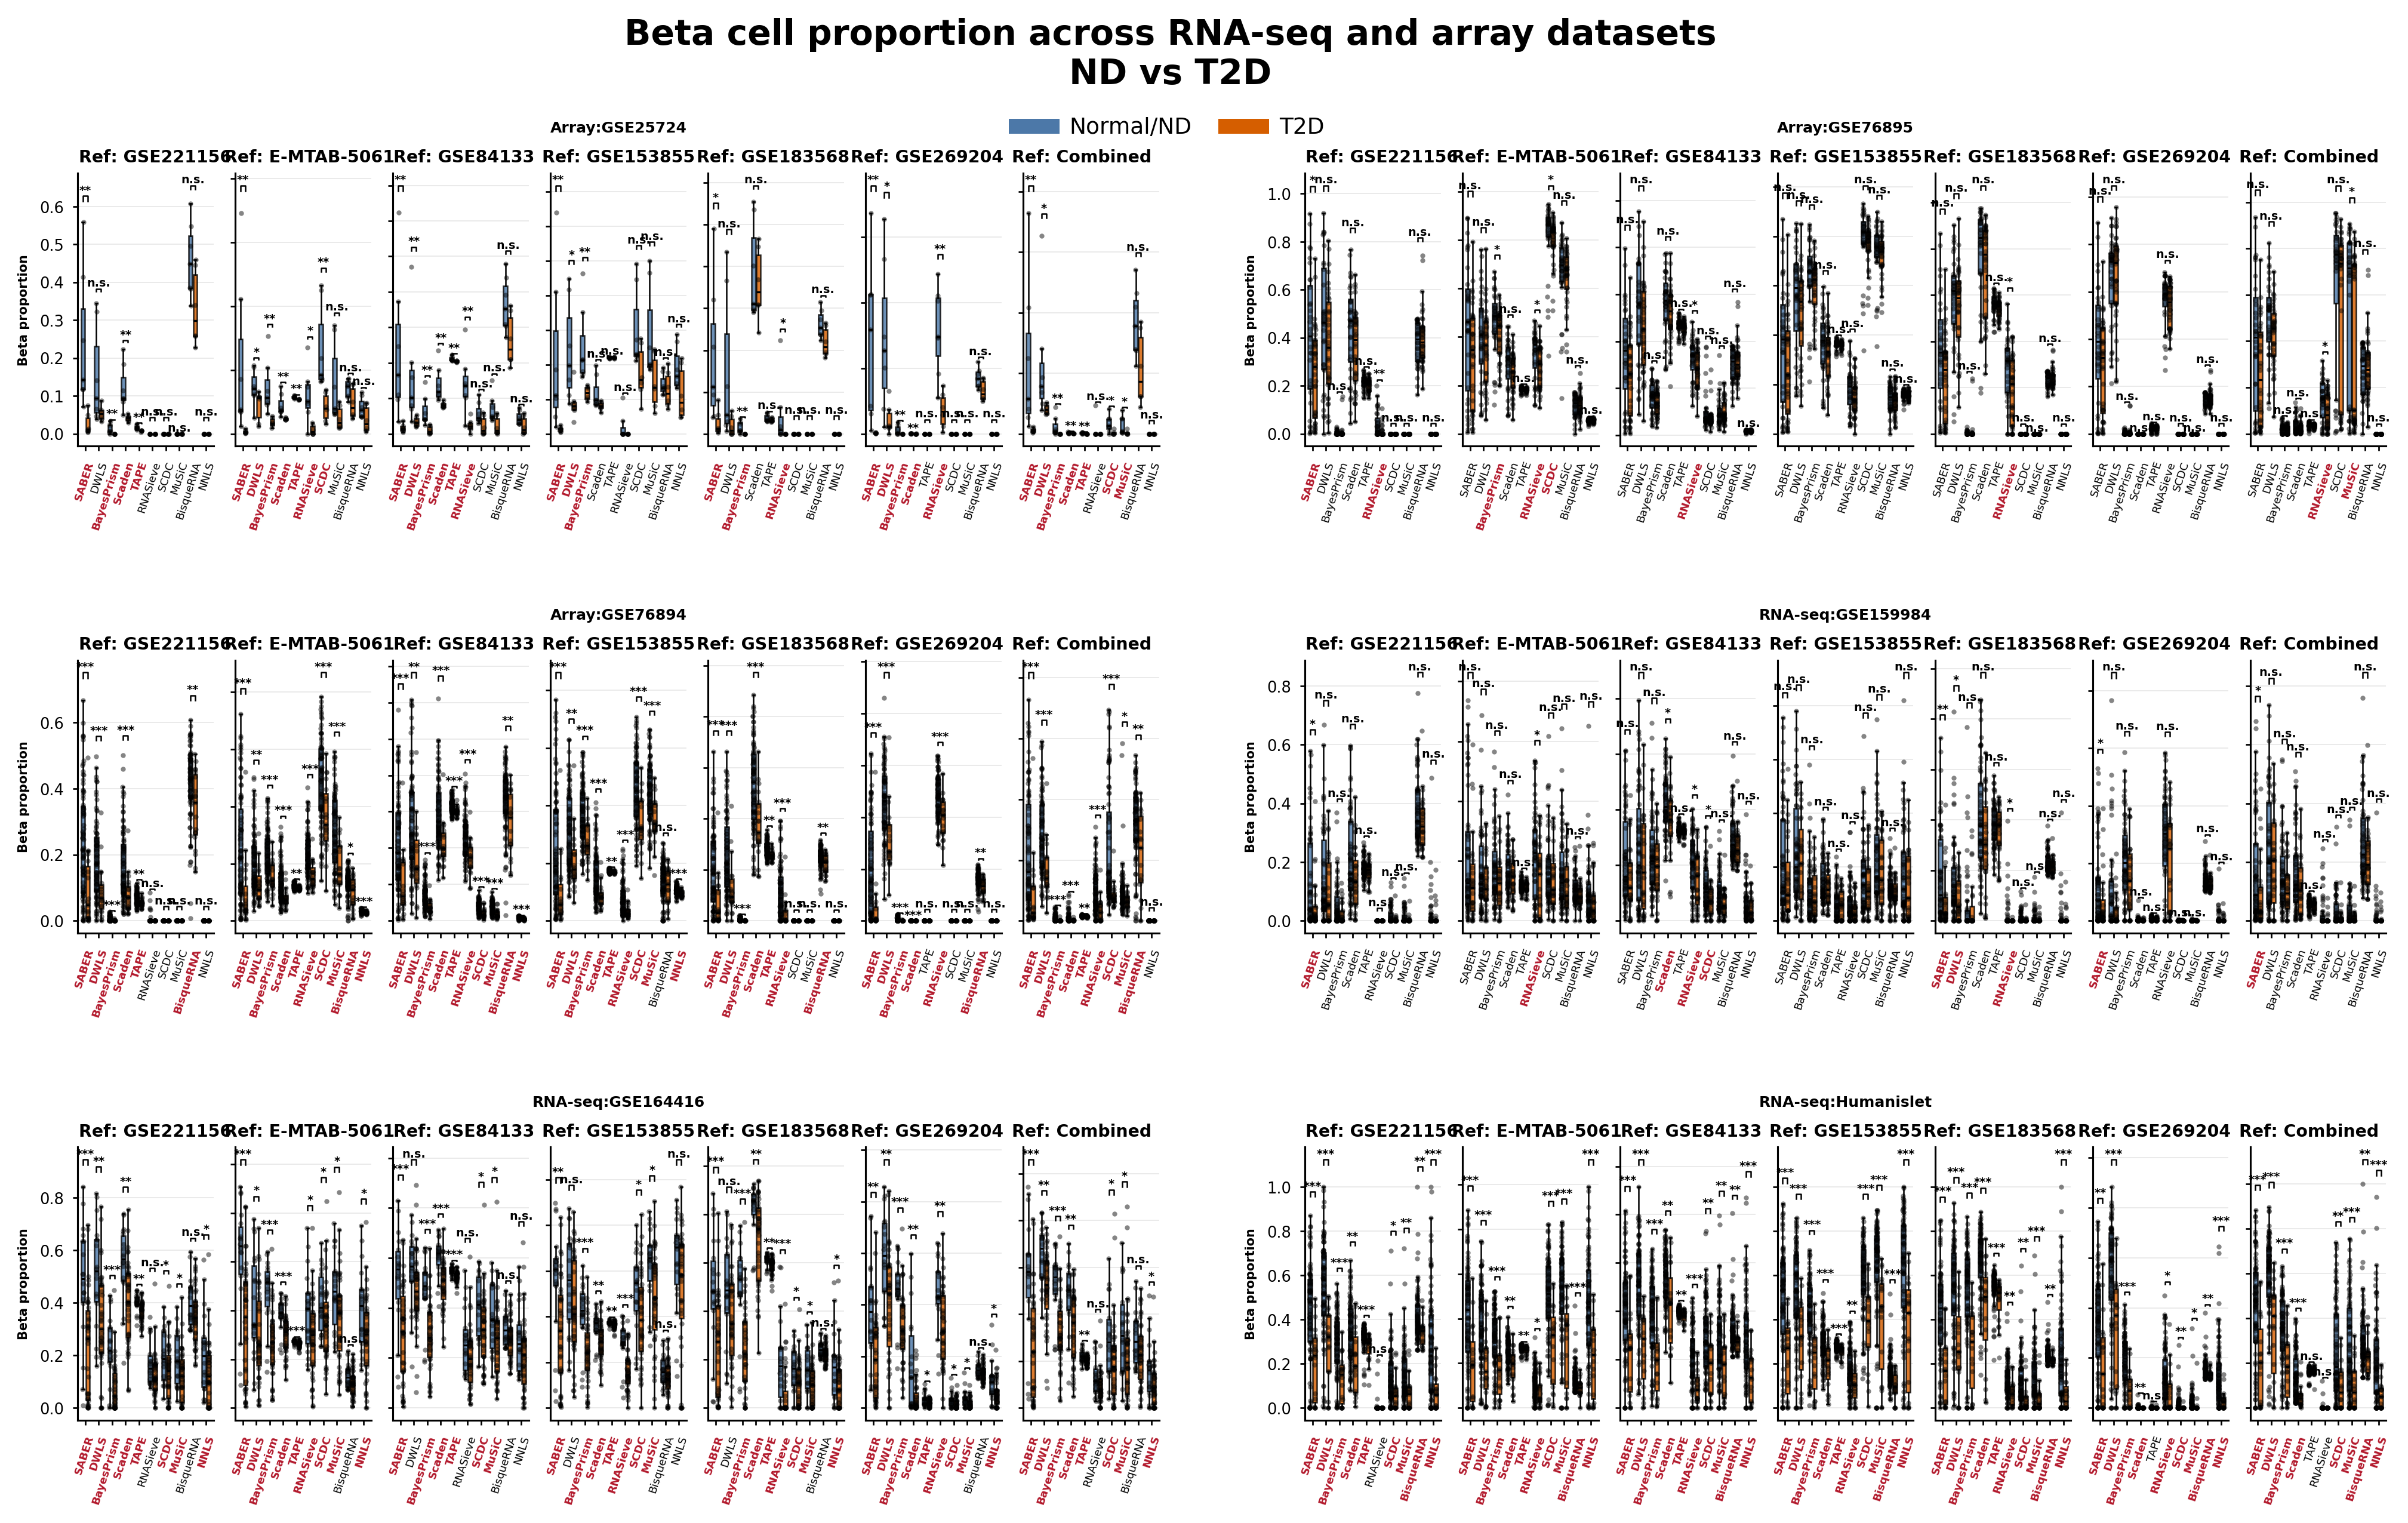

In [4]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.titlesize": 7.8,
        "axes.labelsize": 8.2,
        "axes.linewidth": 0.75,
        "axes.edgecolor": "black",
        "xtick.labelsize": 4.8,
        "ytick.labelsize": 6.2,
        "xtick.major.width": 0.65,
        "ytick.major.width": 0.65,
        "xtick.major.size": 2.0,
        "ytick.major.size": 2.0,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "legend.frameon": False,
    }
)
method_file_list = [x["file_name"] for x in METHODS]
method_display_list = [x["display_name"] for x in METHODS]
celltype = T2D_BOXPLOTS_CELLTYPE
datasets = OrderedDict()
for dataset_key, dataset_cfg in ALL_BULK_DATASETS.items():
    if not "condition" in pd.read_csv(dataset_cfg["meta_path"], nrows=0).columns:
        continue
    datasets[dataset_cfg["bulk_label"]] = OrderedDict()
    for ref_key, ref_label in REFERENCE_CONFIGS.items():
        datasets[dataset_cfg["bulk_label"]][ref_label] = {
            "meta_path": dataset_cfg["meta_path"],
            "result_dir": dataset_cfg["result_dir"],
            "ref_key": ref_key,
        }
palette = {"ND": "#4C78A8", "T2D": "#D55E00", "T3cD": "#7B6D8D"}
label_map = {"ND": "Normal/ND", "T2D": "T2D", "T3cD": "T3cD"}


def get_all_data(meta_path, result_dir, method_file_list, ref_key, verbose=False):
    all_data = {}
    metadata = pd.read_csv(meta_path, index_col=0)
    metadata.index = metadata.index.astype(str)
    metadata["condition_raw"] = metadata["condition"]
    metadata["condition"] = metadata["condition"].map(normalize_condition)
    for method in method_file_list:
        pred_path = os.path.join(result_dir, f"{method}_{ref_key}.csv")
        pred = pd.read_csv(pred_path, index_col=0)
        pred.index = pred.index.astype(str)
        common = metadata.index.intersection(pred.index)
        all_data[method] = pd.concat([metadata.loc[common], pred.loc[common]], axis=1)
    return all_data


def draw_group_header(header_ax, bulk_label, ref_labels):
    header_ax.axis("off")
    header_ax.text(
        0.5,
        0.72,
        bulk_label,
        ha="center",
        va="center",
        fontsize=6.0,
        fontweight="bold",
        transform=header_ax.transAxes,
    )
    n_ref = len(ref_labels)
    for i, ref_label in enumerate(ref_labels):
        x = (i + 0.5) / n_ref
        header_ax.text(
            x,
            0.18,
            f"Ref: {ref_label}",
            ha="center",
            va="center",
            fontsize=6.8,
            fontweight="bold",
            transform=header_ax.transAxes,
        )


def draw_ref_subplot(ax, all_data, celltype, g1, g2, show_ylabel=False):
    width = 0.4
    centers = np.arange(len(method_file_list)) * 1.32
    significant_indices = []
    for i, method in enumerate(method_file_list):
        df = all_data.get(method)
        values = df[["condition", celltype]].copy()
        values[celltype] = pd.to_numeric(values[celltype], errors="coerce")
        sub1 = values.loc[values["condition"] == g1, celltype].dropna()
        sub2 = values.loc[values["condition"] == g2, celltype].dropna()
        pos1 = centers[i] - 0.235
        pos2 = centers[i] + 0.235
        assert not (len(sub1) == 0 and len(sub2) == 0)
        bp1 = ax.boxplot(
            [sub1],
            positions=[pos1],
            widths=width,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 0.8},
            boxprops={"linewidth": 0.6, "color": "black"},
            whiskerprops={"linewidth": 0.6, "color": "black"},
            capprops={"linewidth": 0.6, "color": "black"},
        )
        for patch in bp1["boxes"]:
            patch.set_facecolor(palette[g1])
            patch.set_alpha(0.82)
        rng1 = np.random.default_rng(1000 + i).normal(pos1, 0.028, size=len(sub1))
        ax.scatter(rng1, sub1, color="black", s=4.0, alpha=0.48, linewidths=0, zorder=3)
        bp2 = ax.boxplot(
            [sub2],
            positions=[pos2],
            widths=width,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "black", "linewidth": 0.8},
            boxprops={"linewidth": 0.6, "color": "black"},
            whiskerprops={"linewidth": 0.6, "color": "black"},
            capprops={"linewidth": 0.6, "color": "black"},
        )
        for patch in bp2["boxes"]:
            patch.set_facecolor(palette[g2])
            patch.set_alpha(0.82)
        rng2 = np.random.default_rng(2000 + i).normal(pos2, 0.028, size=len(sub2))
        ax.scatter(rng2, sub2, color="black", s=4.0, alpha=0.48, linewidths=0, zorder=3)
        assert len(sub1) > 0 and len(sub2) > 0
        _, p = mannwhitneyu(sub1, sub2, alternative="two-sided")
        label = p_to_star(p)
        if p < 0.05:
            significant_indices.append(i)
        ymax = max(sub1.max(), sub2.max())
        ymin = min(sub1.min(), sub2.min())
        h = (ymax - ymin) * 0.1 if ymax > ymin else 0.035
        y = ymax + h
        ax.plot([pos1, pos1, pos2, pos2], [y, y + h * 0.25, y + h * 0.25, y], lw=0.6, c="black")
        ax.text(
            (pos1 + pos2) / 2,
            y + h * 0.25,
            label,
            ha="center",
            va="bottom",
            fontsize=4.6,
            fontweight="bold",
        )
    ax.set_xticks(centers)
    xtick_labels = ax.set_xticklabels(
        method_display_list, rotation=72, ha="right", rotation_mode="anchor", fontsize=4.4
    )
    for idx in significant_indices:
        xtick_labels[idx].set_color("#B2182B")
        xtick_labels[idx].set_fontweight("bold")
    if show_ylabel:
        ax.set_ylabel("Beta proportion", fontsize=5.0, fontweight="bold")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.36, alpha=0.7)
    ax.set_axisbelow(True)


def plot_all_combinations(comparison_name, g1, g2, save_prefix, verbose=False):
    bulk_items = list(datasets.items())
    n_bulk = len(bulk_items)
    outer_cols = 2
    outer_rows = math.ceil(n_bulk / outer_cols)
    fig = plt.figure(figsize=(13.8, 2.95 * outer_rows))
    outer_gs = fig.add_gridspec(
        outer_rows,
        outer_cols,
        left=0.058,
        right=0.992,
        bottom=0.065,
        top=0.89,
        wspace=0.135,
        hspace=0.46,
    )
    for bulk_idx, (bulk_label, ref_dict) in enumerate(bulk_items):
        outer_row = bulk_idx // outer_cols
        outer_col = bulk_idx % outer_cols
        ref_labels = list(ref_dict.keys())
        inner_gs = outer_gs[outer_row, outer_col].subgridspec(
            2, len(ref_dict), height_ratios=[0.2, 1.0], hspace=0.035, wspace=0.16
        )
        header_ax = fig.add_subplot(inner_gs[0, :])
        draw_group_header(header_ax=header_ax, bulk_label=bulk_label, ref_labels=ref_labels)
        for ref_idx, (ref_label, cfg) in enumerate(ref_dict.items()):
            ax = fig.add_subplot(inner_gs[1, ref_idx])
            all_data = get_all_data(
                cfg["meta_path"],
                cfg["result_dir"],
                method_file_list,
                cfg["ref_key"],
                verbose=verbose,
            )
            draw_ref_subplot(
                ax=ax, all_data=all_data, celltype=celltype, g1=g1, g2=g2, show_ylabel=ref_idx == 0
            )
    total_slots = outer_rows * outer_cols
    for empty_idx in range(n_bulk, total_slots):
        outer_row = empty_idx // outer_cols
        outer_col = empty_idx % outer_cols
        empty_ax = fig.add_subplot(outer_gs[outer_row, outer_col])
        empty_ax.axis("off")
    handles = [
        Line2D([0], [0], color=palette[g1], lw=6, label=label_map.get(g1, g1)),
        Line2D([0], [0], color=palette[g2], lw=6, label=label_map.get(g2, g2)),
    ]
    fig.suptitle(
        f"Beta cell proportion across RNA-seq and array datasets\n{comparison_name}",
        fontsize=14,
        fontweight="bold",
        y=0.95,
    )
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.9),
        ncol=2,
        frameon=False,
        fontsize=9,
        handlelength=1.6,
        columnspacing=1.5,
    )
    for axis in fig.axes:
        axis.tick_params(axis="both", length=2.0, width=0.65, color="black")
        for spine in axis.spines.values():
            spine.set_linewidth(0.75)
            spine.set_color("black")
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
    save_dir = "/Path/to/output/pancreas"
    os.makedirs(save_dir, exist_ok=True)
    pdf_path = os.path.join(save_dir, f"{save_prefix}.pdf")
    plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_all_combinations(
    comparison_name="ND vs T2D",
    g1="ND",
    g2="T2D",
    save_prefix="t2d_beta_all_bulk_reference_grouped_compact_v2",
    verbose=False,
)


## Summarize beta-cell ND–T2D consistency

Classify beta-cell group differences across methods and references and save the heatmap and its long-form statistics table.

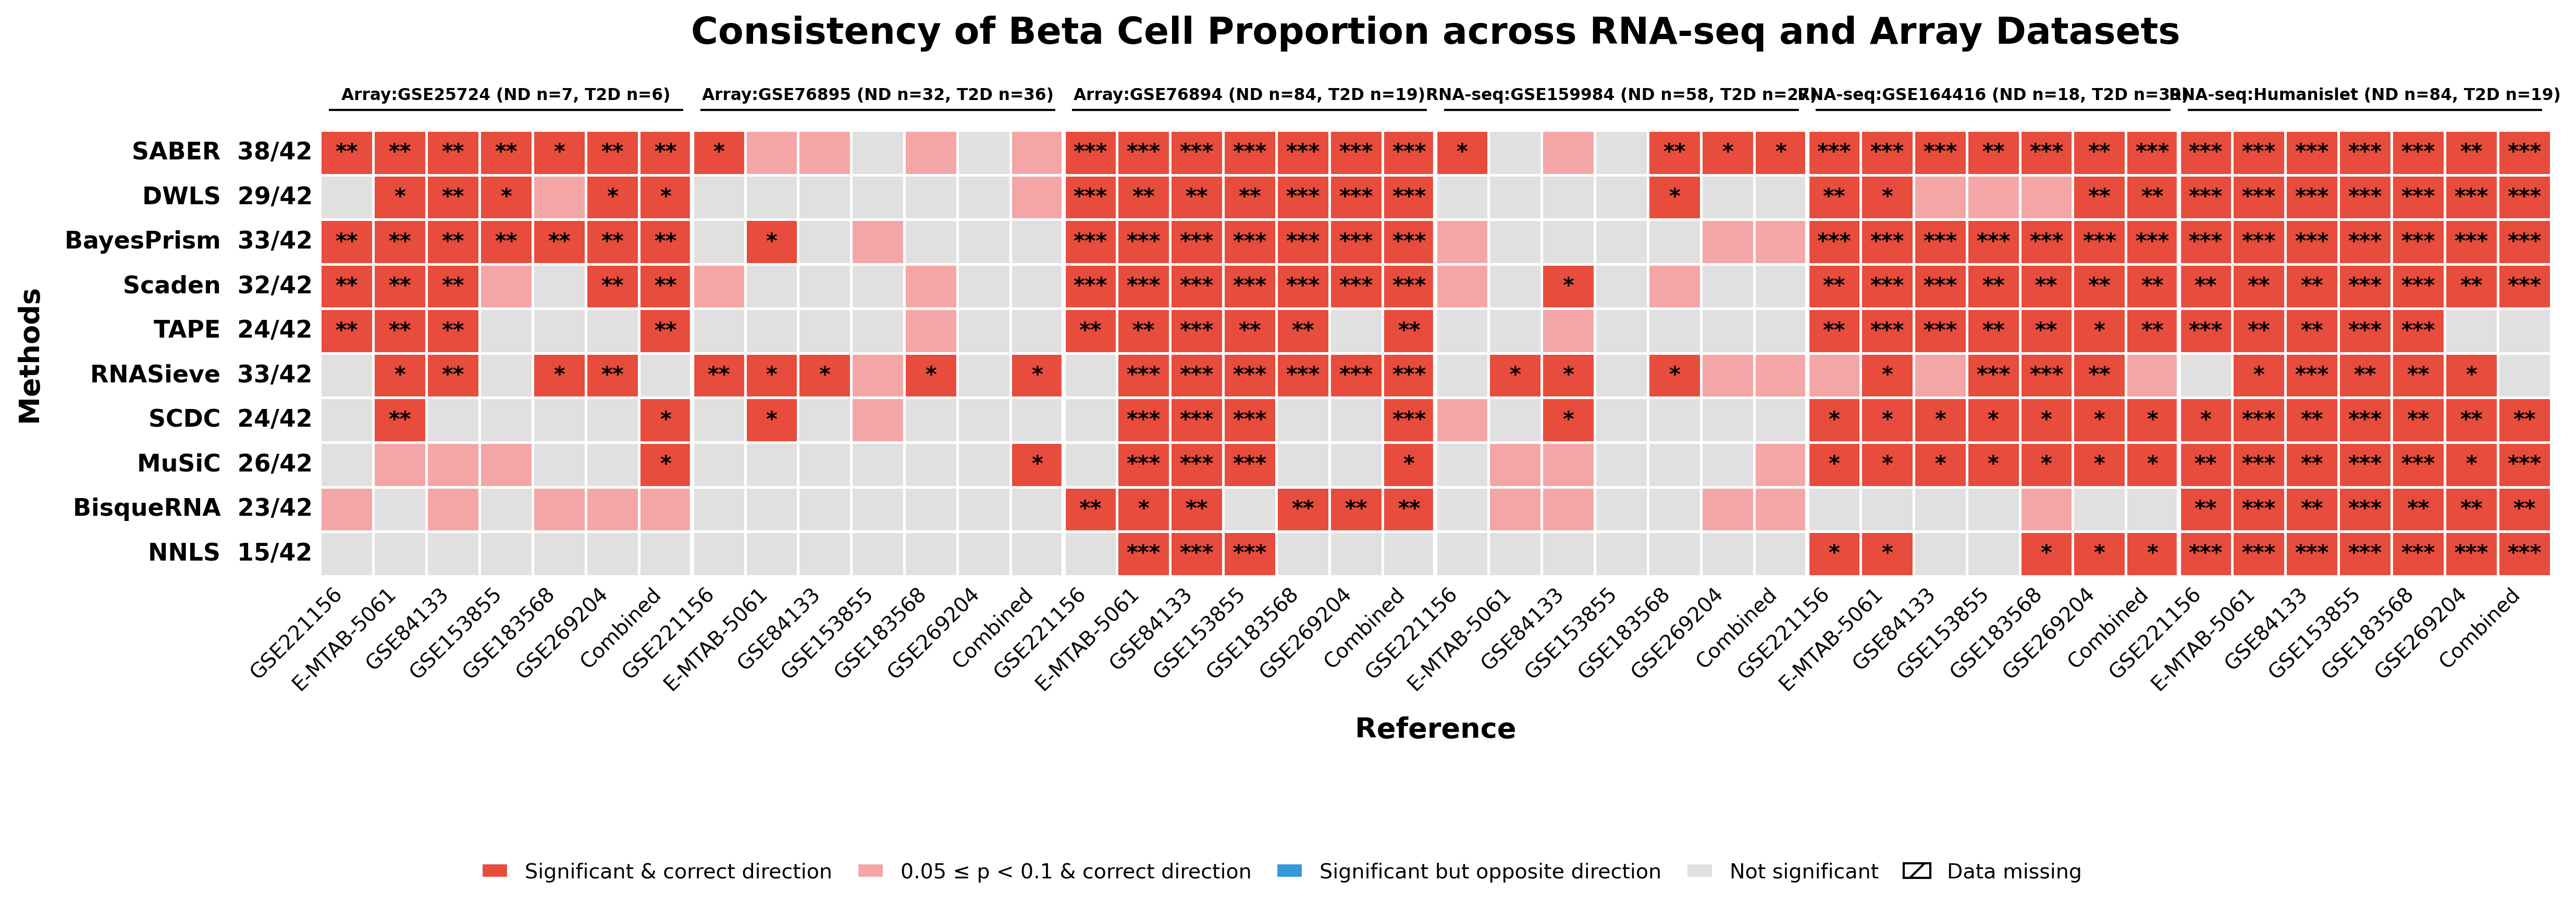

In [5]:
plt.rcParams.update(STYLE_IMMUNE_HEATMAP)
method_file_list = [x["file_name"] for x in METHODS]
method_display_list = [x["display_name"] for x in METHODS]
celltype = T2D_BOXPLOTS_CELLTYPE
scenarios = OrderedDict()
for dataset_key, dataset_cfg in ALL_BULK_DATASETS.items():
    if not "condition" in pd.read_csv(dataset_cfg["meta_path"], nrows=0).columns:
        continue
    nd_n = 0
    t2d_n = 0
    found_prediction_for_n = False
    for ref_key_for_n in REFERENCE_CONFIGS.keys():
        if found_prediction_for_n:
            break
        for method_for_n in method_file_list:
            pred_path_for_n = os.path.join(
                dataset_cfg["result_dir"], f"{method_for_n}_{ref_key_for_n}.csv"
            )
            nd_n, t2d_n = count_analysis_samples(
                dataset_cfg["meta_path"], pred_path_for_n, celltype=celltype
            )
            found_prediction_for_n = True
            break
    bulk_label_with_n = f"{dataset_cfg['bulk_label']} (ND n={nd_n}, T2D n={t2d_n})"
    for ref_key, ref_label in REFERENCE_CONFIGS.items():
        scenarios[f"{bulk_label_with_n}|{ref_label}"] = condition_scenario(
            bulk_label_with_n, ref_label, dataset_cfg, ref_key
        )
scenario_names = list(scenarios.keys())
p_values_dict = {m: {s: np.nan for s in scenario_names} for m in method_file_list}
diff_dict = {m: {s: np.nan for s in scenario_names} for m in method_file_list}
nd_n_dict = {m: {s: 0 for s in scenario_names} for m in method_file_list}
t2d_n_dict = {m: {s: 0 for s in scenario_names} for m in method_file_list}
for s_name, cfg in scenarios.items():
    metadata = pd.read_csv(cfg["meta_path"], index_col=0)
    metadata.index = metadata.index.astype(str)
    metadata["condition"] = metadata["condition"].map(normalize_condition)
    g1 = cfg["g1"]
    g2 = cfg["g2"]
    for method in method_file_list:
        pred_path = os.path.join(cfg["result_dir"], f"{method}_{cfg['ref_key']}.csv")
        pred = pd.read_csv(pred_path, index_col=0)
        pred.index = pred.index.astype(str)
        common = metadata.index.intersection(pred.index)
        df = pd.concat([metadata.loc[common], pred.loc[common]], axis=1)
        df[celltype] = pd.to_numeric(df[celltype], errors="coerce")
        sub1 = df.loc[df["condition"] == g1, celltype].dropna()
        sub2 = df.loc[df["condition"] == g2, celltype].dropna()
        assert len(sub1) > 0 and len(sub2) > 0
        _, p = mannwhitneyu(sub1, sub2, alternative="two-sided")
        diff = sub2.mean() - sub1.mean()
        p_values_dict[method][s_name] = p
        diff_dict[method][s_name] = diff
        nd_n_dict[method][s_name] = len(sub1)
        t2d_n_dict[method][s_name] = len(sub2)
sig_matrix = pd.DataFrame(index=method_file_list, columns=scenario_names, dtype=float)
annot_matrix = pd.DataFrame(index=method_file_list, columns=scenario_names, dtype=object)
for method in method_file_list:
    for s in scenario_names:
        p = p_values_dict[method][s]
        diff = diff_dict[method][s]
        assert not (pd.isna(p) or pd.isna(diff))
        is_sig = p < 0.05
        is_trend = 0.05 <= p < 0.1
        is_correct_dir = diff < 0
        if is_sig and is_correct_dir:
            sig_matrix.loc[method, s] = 3.0
            annot_matrix.loc[method, s] = p_to_star(p, include_near=True, nan_label="N/A")
        elif is_trend and is_correct_dir:
            sig_matrix.loc[method, s] = 2.0
            annot_matrix.loc[method, s] = ""
        elif is_sig and (not is_correct_dir):
            sig_matrix.loc[method, s] = 0.0
            annot_matrix.loc[method, s] = p_to_star(p, include_near=True, nan_label="N/A")
        else:
            sig_matrix.loc[method, s] = 1.0
            annot_matrix.loc[method, s] = ""
consistency_scores = ((sig_matrix == 3.0) | (sig_matrix == 2.0)).sum(axis=1).astype(int)
total_scenarios = len(scenario_names)
row_labels = [
    f"{display}  {score}/{total_scenarios}"
    for display, score in zip(method_display_list, consistency_scores)
]
sig_matrix.index = row_labels
annot_matrix.index = row_labels
ref_labels = [scenarios[s]["ref_label"] for s in scenario_names]
sig_matrix.columns = ref_labels
annot_matrix.columns = ref_labels
bulk_to_cols = OrderedDict()
for i, s in enumerate(scenario_names):
    bulk = scenarios[s]["bulk_label"]
    bulk_to_cols.setdefault(bulk, []).append(i)
fig, ax = plt.subplots(figsize=(16.4, 6.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
cmap = ListedColormap(SIGNIFICANCE_COLORS)
norm = BoundaryNorm(SIGNIFICANCE_BOUNDS, cmap.N)
sns.heatmap(
    sig_matrix,
    cmap=cmap,
    norm=norm,
    annot=annot_matrix,
    fmt="",
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"size": 10, "weight": "bold", "color": "black"},
    ax=ax,
)
for text in ax.texts:
    text.set_color("black")
    text.set_fontweight("bold")
ax.set_title(
    "Consistency of Beta Cell Proportion across RNA-seq and Array Datasets",
    fontsize=17,
    fontweight="bold",
    color="black",
    pad=40,
)
ax.set_xlabel("Reference", fontsize=13, fontweight="bold", color="black", labelpad=10)
ax.set_ylabel("Methods", fontsize=13, fontweight="bold", color="black", labelpad=10)
ax.tick_params(axis="x", rotation=45, labelsize=9.5, length=0, colors="black")
ax.tick_params(axis="y", rotation=0, labelsize=11, length=0, colors="black")
for tick in ax.get_xticklabels():
    tick.set_ha("right")
    tick.set_color("black")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_color("black")
n_methods = len(method_file_list)
for bulk_label, col_indices in bulk_to_cols.items():
    start_col = col_indices[0]
    end_col = col_indices[-1]
    x_center = (start_col + end_col + 1) / 2
    ax.text(
        x_center,
        -0.78,
        bulk_label,
        ha="center",
        va="center",
        fontsize=7.5,
        fontweight="bold",
        color="black",
        clip_on=False,
    )
    ax.hlines(
        y=-0.46,
        xmin=start_col + 0.16,
        xmax=end_col + 0.84,
        colors="black",
        linewidth=1.0,
        clip_on=False,
    )
    if start_col > 0:
        ax.vlines(x=start_col, ymin=0, ymax=n_methods, colors="white", linewidth=2.0)
for text in ax.texts:
    text.set_color("black")
legend_elements = consistency_legend_handles()
fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.035),
    ncol=5,
    frameon=False,
    fontsize=9.5,
    handlelength=1.3,
    columnspacing=1.2,
)
for text in fig.texts:
    text.set_color("black")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.subplots_adjust(left=0.125, right=0.995, top=0.76, bottom=0.3)
save_dir = SAVE_DIR
os.makedirs(save_dir, exist_ok=True)
pdf_path = os.path.join(save_dir, "t2d_beta_consistency_heatmap_grouped.pdf")
plt.savefig(pdf_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
records = []
for method, display_name in zip(method_file_list, method_display_list):
    for s in scenario_names:
        p = p_values_dict[method][s]
        diff = diff_dict[method][s]
        assert not (pd.isna(p) or pd.isna(diff))
        if p < 0.05 and diff < 0:
            result = "Correct_significant"
        elif 0.05 <= p < 0.1 and diff < 0:
            result = "Correct_near"
        elif p < 0.05:
            result = "Opposite_significant"
        else:
            result = "Not_significant"
        records.append(
            {
                "Celltype": celltype,
                "Method": display_name,
                "Bulk_dataset": scenarios[s]["bulk_label"].split(" (ND n=")[0],
                "Reference": scenarios[s]["ref_label"],
                "ND_n": nd_n_dict[method][s],
                "T2D_n": t2d_n_dict[method][s],
                "Difference": diff,
                "P_value": p,
                "Result": result,
            }
        )
pd.DataFrame(records).to_csv(
    os.path.splitext(pdf_path)[0] + ".csv", index=False, na_rep="NA"
)


## Benchmark cross-reference consistency

Calculate per-cell-type and per-sample Pearson, CCC, and MAE across references for all non-DISSECT methods.

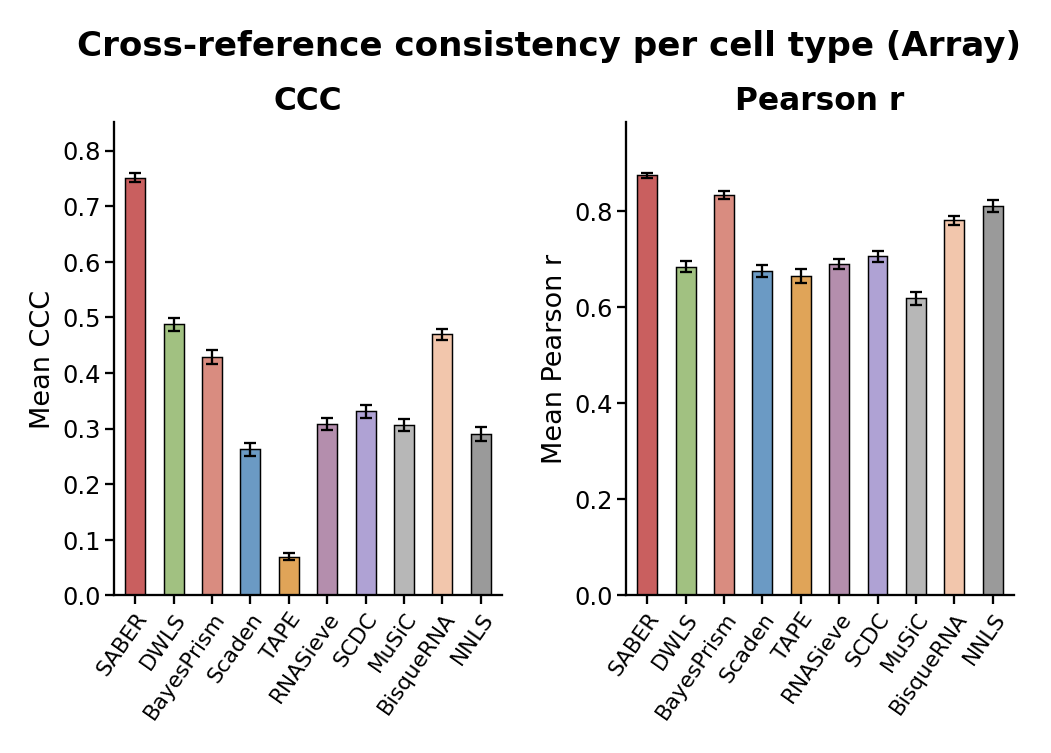

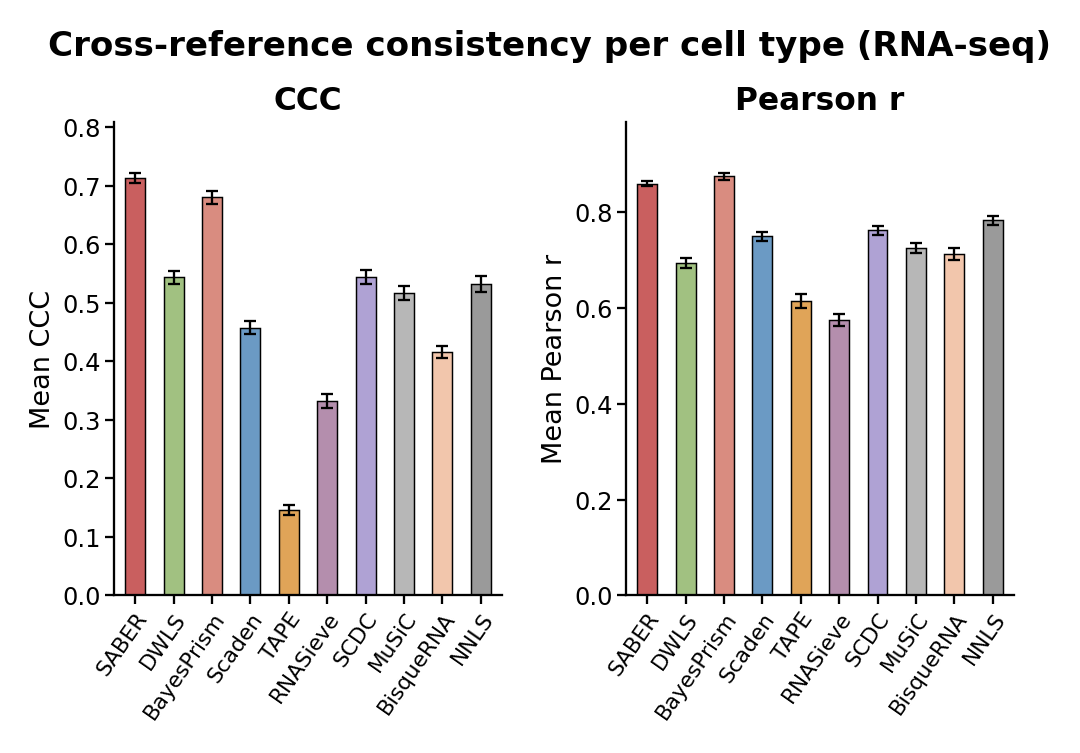

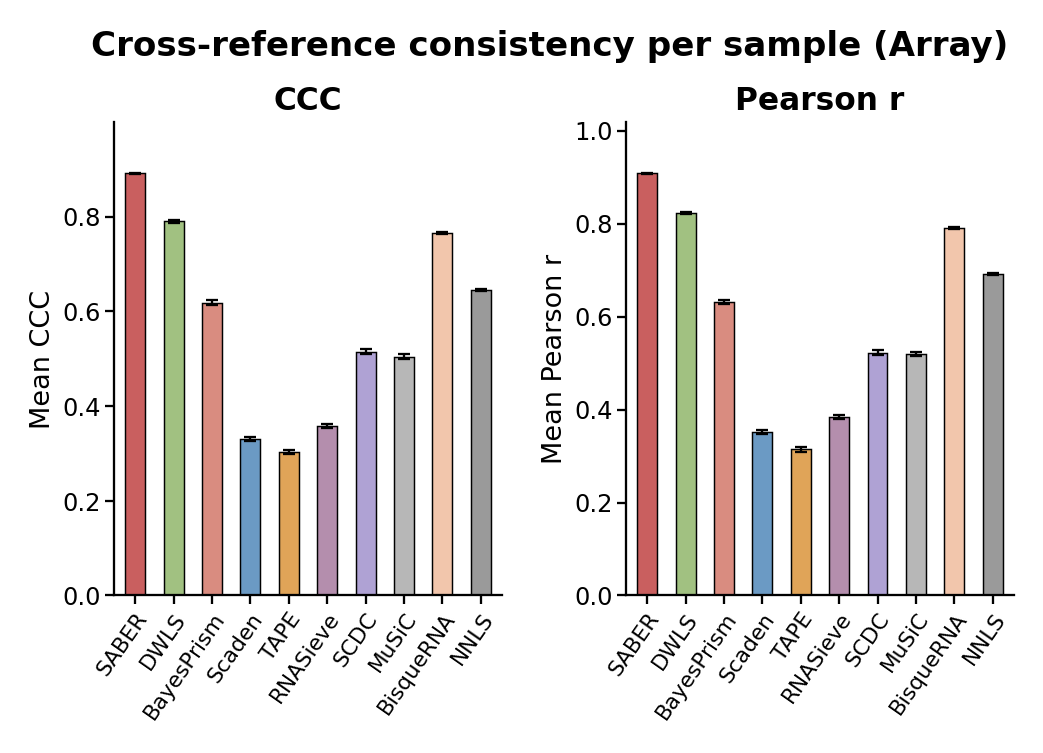

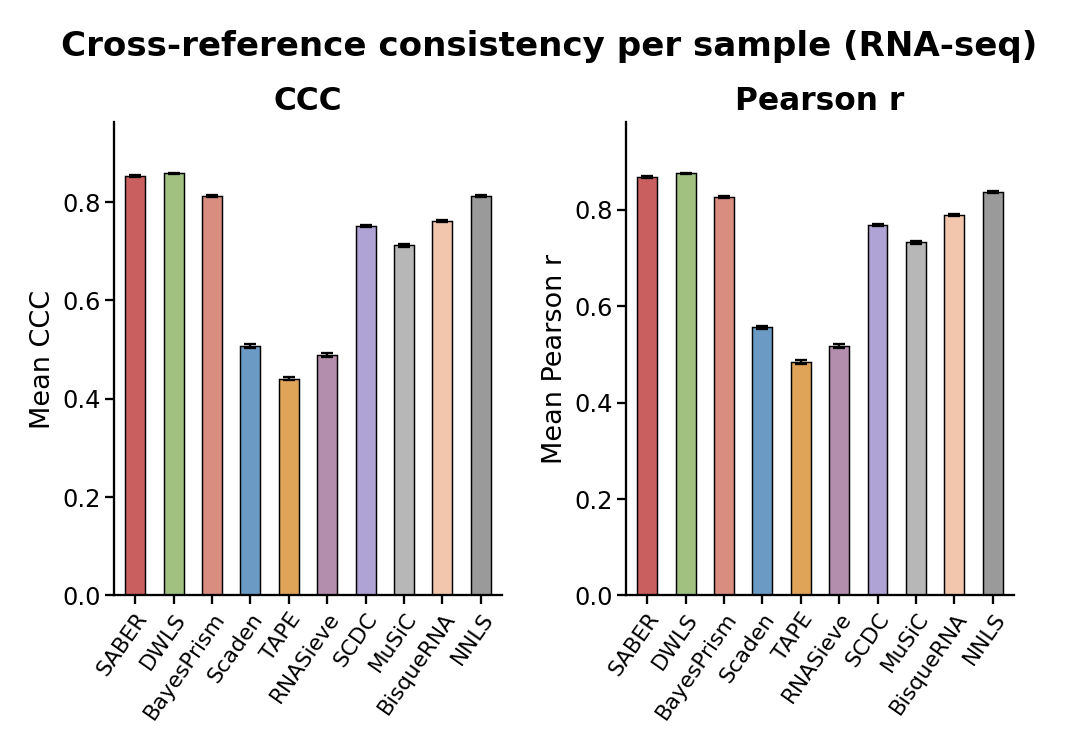

In [6]:


def style_consistency_figure(fig):
    for ax in fig.axes:
        ax.tick_params(axis="both", which="both", direction="out", length=2.2, width=0.55, pad=1.0)
        ax.spines["left"].set_linewidth(0.55)
        ax.spines["bottom"].set_linewidth(0.55)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


plt.rcParams.update(STYLE_BENCHMARK)


def run_pancreas_consistency(
    method_list,
    method_colors,
    method_display_names,
    file_prefix,
    include_method_label=False,
    min_figure_width=3.87,
    figure_width_scale=0.18,
    figure_height=2.05,
):

    dataset_groups = {}
    for s_name, cfg in SCENARIOS.items():
        base_name, ref_suffix = s_name.split("_Ref", 1)
        ref_name = "Ref" + ref_suffix
        cfg["ref_name"] = ref_name
        is_array = (
            base_name.lower().startswith("array")
            or "/array" in cfg.get("meta_path", "").lower()
            or "/array" in cfg.get("result_dir", "").lower()
        )
        cfg["platform"] = "Array" if is_array else "RNA-seq"
        dataset_groups.setdefault(base_name, {})
        dataset_groups[base_name][ref_name] = s_name

    def _to_clean_arrays(y_true, y_pred):
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        return (y_true[mask], y_pred[mask])

    def safe_pearsonr(y_true, y_pred):
        y_true, y_pred = _to_clean_arrays(y_true, y_pred)
        if len(y_true) < 2:
            return np.nan
        if np.std(y_true, ddof=1) == 0 or np.std(y_pred, ddof=1) == 0:
            return np.nan
        r_val, _ = pearsonr(y_true, y_pred)
        return r_val

    def safe_ccc(y_true, y_pred):
        y_true, y_pred = _to_clean_arrays(y_true, y_pred)
        if len(y_true) < 2:
            return np.nan
        mean_true = np.mean(y_true)
        mean_pred = np.mean(y_pred)
        var_true = np.var(y_true)
        var_pred = np.var(y_pred)
        covariance = np.mean((y_true - mean_true) * (y_pred - mean_pred))
        denominator = var_true + var_pred + (mean_true - mean_pred) ** 2
        if np.isclose(denominator, 0.0, atol=1e-15, rtol=0.0):
            return np.nan
        return 2.0 * covariance / denominator

    def safe_mae(y_true, y_pred):
        y_true, y_pred = _to_clean_arrays(y_true, y_pred)
        if len(y_true) == 0:
            return np.nan
        return np.mean(np.abs(y_true - y_pred))

    def compute_metrics(y_true, y_pred):
        return {
            "PearsonR": safe_pearsonr(y_true, y_pred),
            "CCC": safe_ccc(y_true, y_pred),
            "MAE": safe_mae(y_true, y_pred),
        }

    def load_prediction_for_scenario(method, cfg):
        file_path = os.path.join(cfg["result_dir"], f"{method}_{cfg['ref_key']}.csv")
        df = pd.read_csv(file_path, index_col=0)
        metadata = pd.read_csv(cfg["meta_path"], index_col=0)
        df.index = df.index.astype(str)
        common_idx = df.index.intersection(metadata.index.astype(str))
        df = df.loc[common_idx].copy()
        for ct in BENCHMARK_CELLTYPES:
            df[ct] = pd.to_numeric(df[ct], errors="coerce")
        return df

    celltype_records = []
    sample_records = []
    for method in method_list:
        for dataset_name, refs_dict in dataset_groups.items():
            available_refs = list(refs_dict.keys())
            first_scenario_name = refs_dict[available_refs[0]]
            platform = SCENARIOS[first_scenario_name]["platform"]
            preds = {}
            for ref_key in available_refs:
                s_name = refs_dict[ref_key]
                cfg = SCENARIOS[s_name]
                pred_df = load_prediction_for_scenario(method, cfg)
                preds[ref_key] = pred_df
            for ref_A, ref_B in itertools.combinations(preds.keys(), 2):
                df_A = preds[ref_A]
                df_B = preds[ref_B]
                common_samples = sorted(set(df_A.index).intersection(df_B.index))
                for ct in BENCHMARK_CELLTYPES:
                    vA = df_A.loc[common_samples, ct].values
                    vB = df_B.loc[common_samples, ct].values
                    metrics = compute_metrics(vA, vB)
                    if all((np.isnan(metrics[m]) for m in ["PearsonR", "CCC", "MAE"])):
                        continue
                    celltype_records.append(
                        {
                            "Evaluation": "PerCellType",
                            "Method": method,
                            **(
                                {"Method_Label": method_display_names[method]}
                                if include_method_label
                                else {}
                            ),
                            "Dataset": dataset_name,
                            "Platform": platform,
                            "Ref_A": ref_A,
                            "Ref_B": ref_B,
                            "CellType": ct,
                            "N_Samples": len(common_samples),
                            **metrics,
                        }
                    )
                common_celltypes = [
                    ct for ct in BENCHMARK_CELLTYPES if ct in df_A.columns and ct in df_B.columns
                ]
                for sample in common_samples:
                    vA = df_A.loc[sample, common_celltypes].values
                    vB = df_B.loc[sample, common_celltypes].values
                    metrics = compute_metrics(vA, vB)
                    if all((np.isnan(metrics[m]) for m in ["PearsonR", "CCC", "MAE"])):
                        continue
                    sample_records.append(
                        {
                            "Evaluation": "PerSample",
                            "Method": method,
                            **(
                                {"Method_Label": method_display_names[method]}
                                if include_method_label
                                else {}
                            ),
                            "Dataset": dataset_name,
                            "Platform": platform,
                            "Ref_A": ref_A,
                            "Ref_B": ref_B,
                            "Sample": sample,
                            "N_CellTypes": len(common_celltypes),
                            **metrics,
                        }
                    )
    df_celltype = pd.DataFrame(celltype_records)
    df_sample = pd.DataFrame(sample_records)

    def summarize_by_method(df, evaluation_name):
        metrics = ["PearsonR", "CCC", "MAE"]
        records = []
        for method in method_list:
            method_df = df[df["Method"] == method]
            for metric in metrics:
                values = pd.to_numeric(method_df[metric], errors="coerce").dropna()
                n = len(values)
                if n == 0:
                    mean_val = np.nan
                    sd_val = np.nan
                    sem_val = np.nan
                elif n == 1:
                    mean_val = values.mean()
                    sd_val = 0.0
                    sem_val = 0.0
                else:
                    mean_val = values.mean()
                    sd_val = values.std(ddof=1)
                    sem_val = sd_val / np.sqrt(n)
                records.append(
                    {
                        "Evaluation": evaluation_name,
                        "Method": method,
                        **(
                            {"Method_Label": method_display_names[method]}
                            if include_method_label
                            else {}
                        ),
                        "Metric": metric,
                        "Mean": mean_val,
                        "SD": sd_val,
                        "SEM": sem_val,
                        "Count": n,
                    }
                )
        return pd.DataFrame(records)

    summary_celltype_array = summarize_by_method(
        df_celltype[df_celltype["Platform"] == "Array"], "PerCellType_Array"
    )
    summary_celltype_rnaseq = summarize_by_method(
        df_celltype[df_celltype["Platform"] == "RNA-seq"], "PerCellType_RNAseq"
    )
    summary_sample_array = summarize_by_method(
        df_sample[df_sample["Platform"] == "Array"], "PerSample_Array"
    )
    summary_sample_rnaseq = summarize_by_method(
        df_sample[df_sample["Platform"] == "RNA-seq"], "PerSample_RNAseq"
    )




    def plot_consistency_summary(summary_df, title, output_prefix):
        metrics = [("CCC", "CCC", "Mean CCC"), ("PearsonR", "Pearson r", "Mean Pearson r")]
        available_methods = [m for m in method_list if m in summary_df["Method"].unique()]
        x_spacing = 0.58
        x = np.arange(len(available_methods)) * x_spacing
        bar_width = 0.3
        bar_colors = [method_colors[m] for m in available_methods]
        fig_width = max(min_figure_width, figure_width_scale * len(available_methods) * 2)
        fig_height = figure_height
        fig, axes = plt.subplots(
            1, 2, figsize=(fig_width, fig_height), gridspec_kw={"wspace": 0.32}
        )
        for ax, (metric, panel_title, y_label) in zip(axes, metrics):
            panel_df = (
                summary_df[summary_df["Metric"] == metric]
                .set_index("Method")
                .reindex(available_methods)
            )
            means = panel_df["Mean"].astype(float).values
            sems = panel_df["SEM"].astype(float).fillna(0.0).values
            ax.bar(
                x,
                means,
                yerr=sems,
                color=bar_colors,
                edgecolor="black",
                linewidth=0.35,
                width=bar_width,
                error_kw={"elinewidth": 0.55, "ecolor": "black", "capsize": 1.5, "capthick": 0.55},
            )
            ax.set_title(panel_title, pad=3)
            ax.set_ylabel(y_label, labelpad=1.5)
            ax.set_xticks(x)
            ax.set_xticklabels(
                [method_display_names.get(m, m) for m in available_methods],
                rotation=55,
                ha="right",
                rotation_mode="anchor",
            )
            ax.set_xlim(x[0] - 0.32, x[-1] + 0.32)
            finite_mask = np.isfinite(means + sems)
            data_upper = np.nanmax((means + sems)[finite_mask])
            data_upper = data_upper if data_upper > 0 else 0.1
            ax.set_ylim(0, data_upper * 1.12)
        fig.suptitle(title, fontsize=8.2, fontweight="bold", y=1.03)
        style_consistency_figure(fig)
        plt.tight_layout(pad=0.35, w_pad=0.3)
        fig.savefig(os.path.join(SAVE_DIR, f"{output_prefix}.pdf"), bbox_inches="tight")
        plt.show()

    def save_table(df, filename):
        path = os.path.join(SAVE_DIR, filename)
        df.to_csv(path, index=False)

    save_table(df_celltype, f"{file_prefix}_per_celltype_consistency_raw.csv")
    save_table(summarize_by_method(df_celltype, "PerCellType"), f"{file_prefix}_per_celltype_consistency_summary.csv")
    df_celltype_array = df_celltype[df_celltype["Platform"] == "Array"].copy()
    save_table(df_celltype_array, f"{file_prefix}_array_per_celltype_consistency_raw.csv")
    save_table(summary_celltype_array, f"{file_prefix}_array_per_celltype_consistency_summary.csv")
    plot_consistency_summary(summary_celltype_array, title='Cross-reference consistency per cell type (Array)', output_prefix=f'{file_prefix}_array_per_celltype_consistency_barplot')
    df_celltype_rnaseq = df_celltype[df_celltype["Platform"] == "RNA-seq"].copy()
    save_table(df_celltype_rnaseq, f"{file_prefix}_rnaseq_per_celltype_consistency_raw.csv")
    save_table(
        summary_celltype_rnaseq, f"{file_prefix}_rnaseq_per_celltype_consistency_summary.csv"
    )
    plot_consistency_summary(summary_celltype_rnaseq, title='Cross-reference consistency per cell type (RNA-seq)', output_prefix=f'{file_prefix}_rnaseq_per_celltype_consistency_barplot')
    save_table(df_sample, f"{file_prefix}_per_sample_consistency_raw.csv")
    save_table(summarize_by_method(df_sample, "PerSample"), f"{file_prefix}_per_sample_consistency_summary.csv")
    df_sample_array = df_sample[df_sample["Platform"] == "Array"].copy()
    save_table(df_sample_array, f"{file_prefix}_array_per_sample_consistency_raw.csv")
    save_table(summary_sample_array, f"{file_prefix}_array_per_sample_consistency_summary.csv")
    plot_consistency_summary(summary_sample_array, title='Cross-reference consistency per sample (Array)', output_prefix=f'{file_prefix}_array_per_sample_consistency_barplot')
    df_sample_rnaseq = df_sample[df_sample["Platform"] == "RNA-seq"].copy()
    save_table(df_sample_rnaseq, f"{file_prefix}_rnaseq_per_sample_consistency_raw.csv")
    save_table(summary_sample_rnaseq, f"{file_prefix}_rnaseq_per_sample_consistency_summary.csv")
    plot_consistency_summary(summary_sample_rnaseq, title='Cross-reference consistency per sample (RNA-seq)', output_prefix=f'{file_prefix}_rnaseq_per_sample_consistency_barplot')


run_pancreas_consistency(
    [item["file_name"] for item in METHODS], method_colors, {"Scadenpytorch": "Scaden"}, "Pancreas"
)


## Ablation cross-reference consistency

Apply the identical consistency definitions to SABER ablations and save raw, summary, and plot outputs.

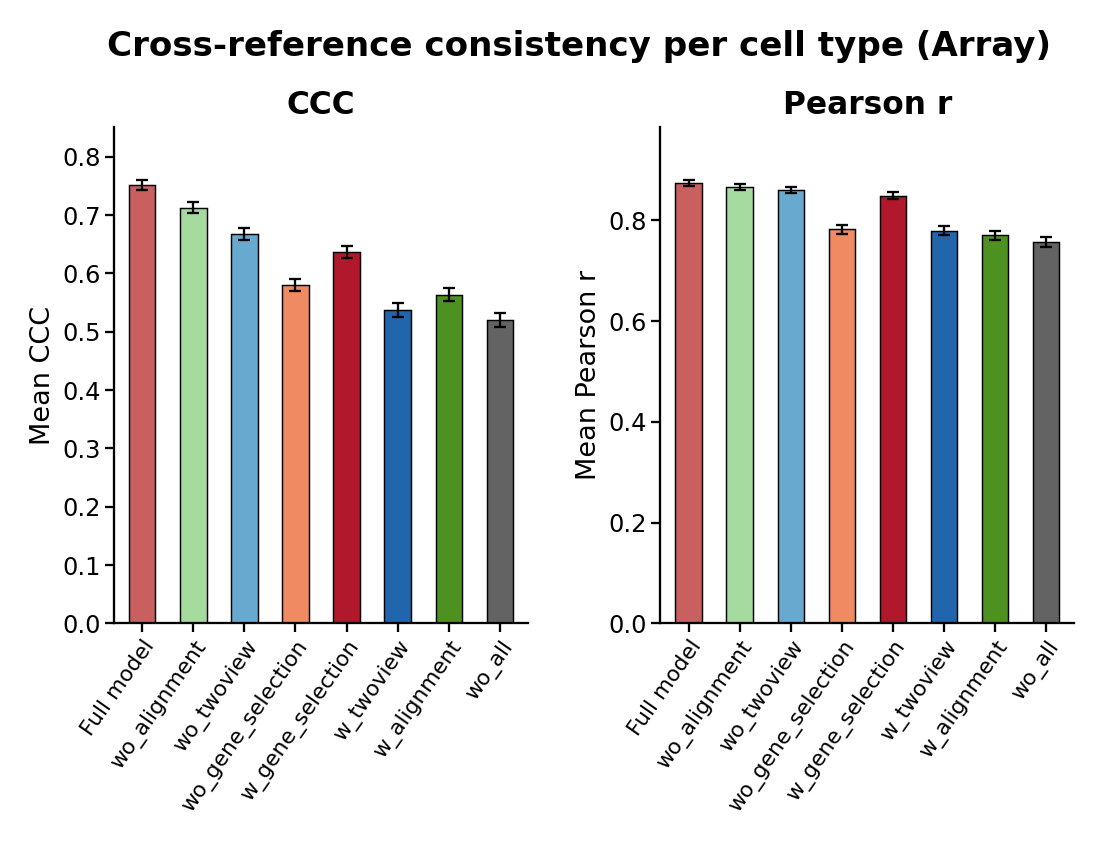

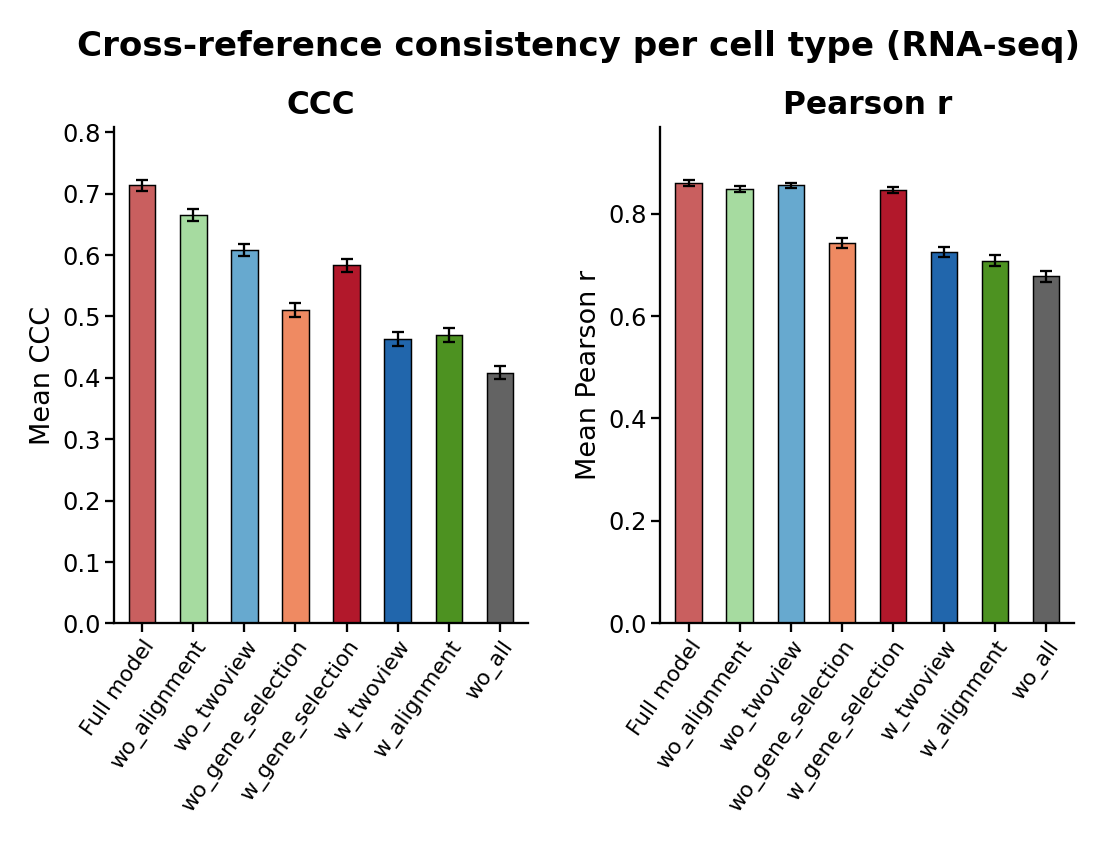

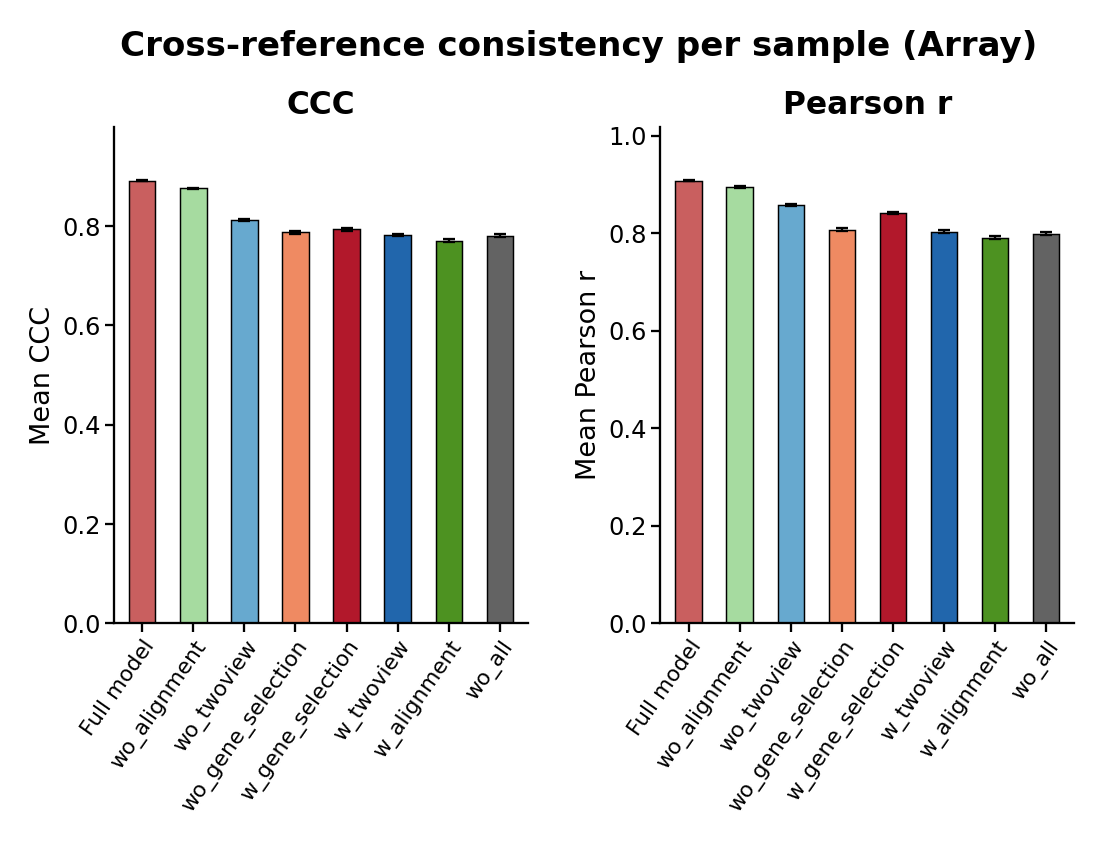

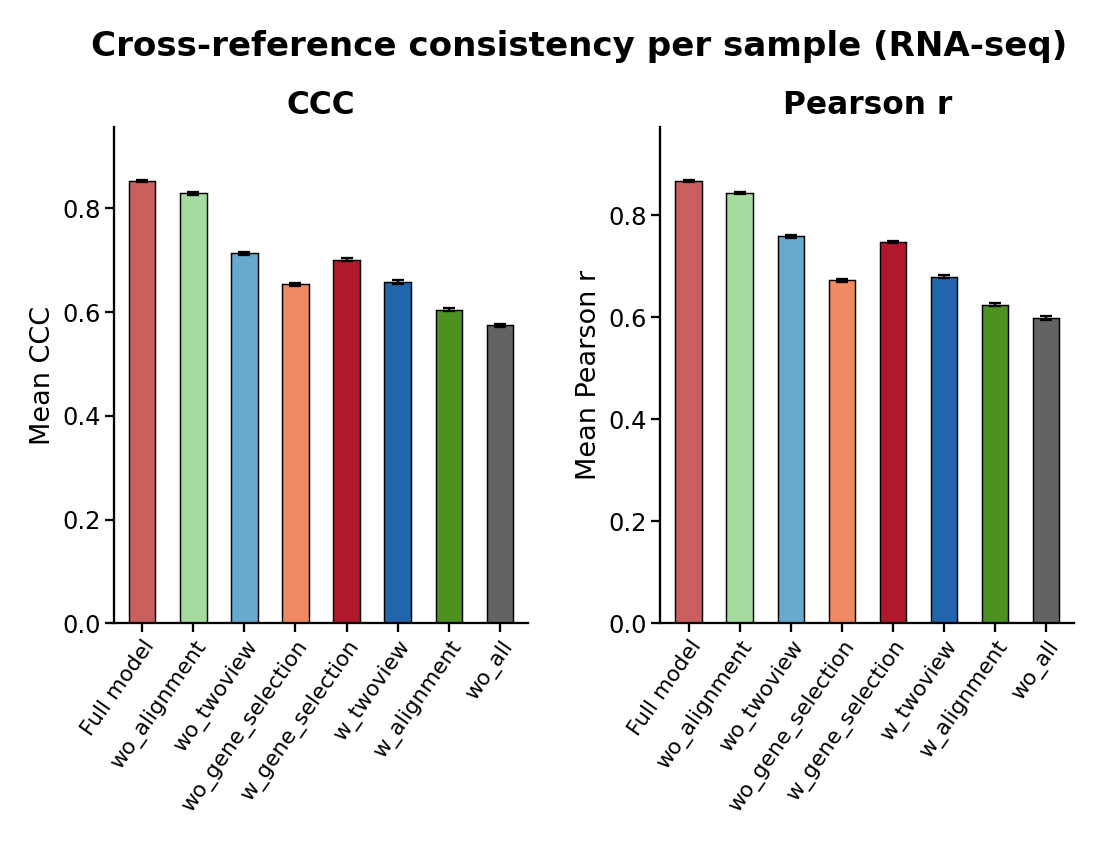

In [7]:
plt.rcParams.update(STYLE_BENCHMARK)
run_pancreas_consistency(
    [
        "SABER", "SABER_wo_alignment", "SABER_wo_twoview", "SABER_wo_gene_selection",
        "SABER_w_gene_selection", "SABER_w_twoview", "SABER_w_alignment", "SABER_wo_all",
    ],
    {
        "SABER": "#C95F5F",
        "SABER_wo_alignment": "#A6DBA0",
        "SABER_wo_twoview": "#67A9CF",
        "SABER_wo_gene_selection": "#EF8A62",
        "SABER_w_gene_selection": "#B2182B",
        "SABER_w_twoview": "#2166AC",
        "SABER_w_alignment": "#4D9221",
        "SABER_wo_all": "#636363",
    },
    {
        "SABER": "Full model",
        "SABER_w_gene_selection": "w_gene_selection",
        "SABER_wo_gene_selection": "wo_gene_selection",
        "SABER_w_twoview": "w_twoview",
        "SABER_wo_twoview": "wo_twoview",
        "SABER_w_alignment": "w_alignment",
        "SABER_wo_alignment": "wo_alignment",
        "SABER_wo_all": "wo_all",
    },
    "pancreas_ablation", True, 4.13, 0.2, 2.15,
)
